# ConvLSTM Flood Prediction Model
## Lake Buhi, Camarines Sur

### System Requirements & Configuration
- **CPU**: AMD Ryzen 5 5600H
- **GPU**: NVIDIA RTX 3050Ti (4GB VRAM)
- **RAM**: 16GB
- **DTM Source**: NAMRIA — Buhi-area clip (BUHI_DTM.tif)

### Available Data:
- ✅ `BUHI_DTM.tif` — Digital Terrain Model (bare-earth elevation)
- ✅ `BUHI_LAKE.shp` (+.cpg, .dbf, .prj, .qmd) — Lake Buhi polygon shapefile
- ✅ `BUHI_Rainfall-Data.csv` — Historical hourly rainfall
- ✅ `BUHI_Riverlevel-Data.csv` — Historical hourly river/lake level
- ✅ `BUHI_station_metadata.csv` — Monitoring station coordinates
- ❌ Historical flood extent maps (not available)

### Flood Mechanism — Lake Buhi Overflow:
Lake Buhi is a natural **dammed lake**. The river-level gauge measures the lake's
water surface elevation. When the lake level **exceeds the bank/overflow threshold**,
water spills over the lake boundary and floods the surrounding low-lying terrain.

### Approach Without Historical Flood Data:
1. **River/Lake Level Prediction** — Train ConvLSTM on rainfall → lake level
2. **Physics-Based Flood Estimation** — Lake shapefile defines the overflow boundary;
   DEM determines where floodwater flows once the lake overflows
3. **Threshold-Based Warnings** — Alert / Alarm / Critical levels for early warning

In [1]:
"""
Cell 1: Environment Setup & Configuration
=========================================
Buhi-only configuration with Lake Buhi shapefile.
"""

import warnings
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

CONFIG = {
    # Hardware constraints
    'MAX_RAM_GB': 12,              # Leave 4GB for system
    'GPU_MEMORY_LIMIT_MB': 3500,   # Leave ~500MB for display

    # DEM Processing
    'DOWNSAMPLE_FACTOR': 4,        # 4× downsample after clipping

    # Study Area — Buhi municipality + lake surroundings (WGS84)
    'STUDY_BOUNDS': {
        'min_lon': 123.40,
        'max_lon': 123.60,
        'min_lat': 13.38,
        'max_lat': 13.50
    },

    # ── File Paths (must live in the same folder as this notebook) ──
    'DEM_DTM_PATH':       'BUHI_DTM.tif',
    'LAKE_SHAPEFILE':     'BUHI_LAKE.shp',
    'RAINFALL_CSV':       'BUHI_Rainfall-Data.csv',
    'RIVERLEVEL_CSV':     'BUHI_Riverlevel-Data.csv',
    'STATION_META_CSV':   'BUHI_station_metadata.csv',

    # Model Parameters
    'INPUT_HOURS': 12,             # Historical window (hours)
    'OUTPUT_HOURS': 6,             # Prediction horizon (hours)
    'BATCH_SIZE': 2,               # Small for 4GB VRAM
    'EPOCHS': 50,

    # River / Lake Level Thresholds (meters)
    # Based on Buhi river level station color codes
    'THRESHOLDS': {
        'normal':   0.0,
        'alert':    0.75,
        'alarm':    0.80,
        'critical': 0.85
    }
}

# ============================================================================
# DISPLAY CONFIGURATION
# ============================================================================
print("=" * 70)
print("FLOOD PREDICTION SYSTEM — BUHI, CAMARINES SUR")
print("=" * 70)

print(f"\n📐 Hardware Configuration:")
print(f"   Max RAM: {CONFIG['MAX_RAM_GB']} GB")
print(f"   GPU Memory Limit: {CONFIG['GPU_MEMORY_LIMIT_MB']} MB")

print(f"\n🗺️  Study Area Bounds (WGS84):")
b = CONFIG['STUDY_BOUNDS']
print(f"   Longitude: {b['min_lon']}° – {b['max_lon']}° E")
print(f"   Latitude:  {b['min_lat']}° – {b['max_lat']}° N")

print(f"\n⚠️  Lake-Level Thresholds:")
for level, value in CONFIG['THRESHOLDS'].items():
    print(f"   {level.capitalize()}: {value} m")

print(f"\n📁 Expected Files:")
for key in ['DEM_DTM_PATH', 'LAKE_SHAPEFILE', 'RAINFALL_CSV',
            'RIVERLEVEL_CSV', 'STATION_META_CSV']:
    print(f"   {CONFIG[key]}")
print("=" * 70)

FLOOD PREDICTION SYSTEM — BUHI, CAMARINES SUR

📐 Hardware Configuration:
   Max RAM: 12 GB
   GPU Memory Limit: 3500 MB

🗺️  Study Area Bounds (WGS84):
   Longitude: 123.4° – 123.6° E
   Latitude:  13.38° – 13.5° N

⚠️  Lake-Level Thresholds:
   Normal: 0.0 m
   Alert: 0.75 m
   Alarm: 0.8 m
   Critical: 0.85 m

📁 Expected Files:
   BUHI_DTM.tif
   BUHI_LAKE.shp
   BUHI_Rainfall-Data.csv
   BUHI_Riverlevel-Data.csv
   BUHI_station_metadata.csv


## Step 1: Import Dependencies

Loads all required packages.  
**Extra dependency**: `geopandas` is needed to read the lake shapefile.

In [2]:
"""
Cell 2: Import Dependencies
============================
"""

import sys
print(f"Python: {sys.version.split()[0]}")

# Core imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
import rasterio
from rasterio.features import rasterize
from rasterio.transform import from_bounds as transform_from_bounds
from pyproj import Transformer, CRS
from scipy.ndimage import zoom, binary_dilation, label, gaussian_filter
import geopandas as gpd
import json
from pathlib import Path
import gc

print(f"pandas:      {pd.__version__}")
print(f"numpy:       {np.__version__}")
print(f"tensorflow:  {tf.__version__}")
print(f"rasterio:    {rasterio.__version__}")
print(f"geopandas:   {gpd.__version__}")
print("\n✅ All packages loaded!")

# Configure TensorFlow for memory efficiency
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"\n🎮 GPU detected: {len(gpus)} device(s)")
        print("   Memory growth enabled (prevents OOM)")
    except RuntimeError as e:
        print(f"⚠️  GPU config error: {e}")
else:
    print("\n⚠️  No GPU detected — will use CPU (slower training)")

Python: 3.12.4
pandas:      3.0.1
numpy:       2.4.2
tensorflow:  2.20.0
rasterio:    1.5.0
geopandas:   1.1.2

✅ All packages loaded!

⚠️  No GPU detected — will use CPU (slower training)


## Step 2: Load Station Metadata + DTM + Lake Shapefile

1. **Station metadata** — reads coordinates from `BUHI_station_metadata.csv`
2. **DTM** — clips the Buhi DTM to the study area and downsamples
3. **Lake shapefile** — rasterizes `BUHI_LAKE.shp` onto the DTM grid to create a
   precise **lake mask**.  This mask defines the overflow boundary in later cells.

STATION METADATA + DTM + LAKE SHAPEFILE PROCESSING

📂 Loading station metadata...
✓ Station metadata loaded: (1, 3)
StationID  Longitude  Latitude
     Buhi    123.509   13.4337

📍 Stations loaded:
   Buhi: 13.43370°N, 123.5090°E

📂 Opening DTM: BUHI_DTM.tif

📊 Original DTM:
   Size: 4065 × 2907 = 11,816,955 px
   CRS:  ESRI:102457
   Bounds: BoundingBox(left=548973.6866, bottom=1474846.543, right=563508.6866, top=1495171.543)
   Resolution: 5.000000 m/px

🔄 Reprojecting WGS84 bounds → DTM CRS...

🔧 Clipping to study area...

✓ Clipped DTM: (2663, 2905)
   Pixels: 7,736,015
   Memory: 29.5 MB
   Filled 1,342,622 NaN with mean (263.2 m)

🔧 Downsampling 4×...
   (2663, 2905) → (666, 726)

📊 Processed DTM Statistics:
   Shape: (666, 726)
   Elevation: 48.91 – 1209.32 m  (mean 263.16, σ 198.87)
   Memory: 1.84 MB

🌊 Low-lying (≤95.5 m): 25.0%

📂 Loading lake shapefile: BUHI_LAKE.shp
   CRS: EPSG:4326
   Features: 15
   Total area: 0.00 (in CRS units)
   Reprojecting lake EPSG:4326 → ESRI:1

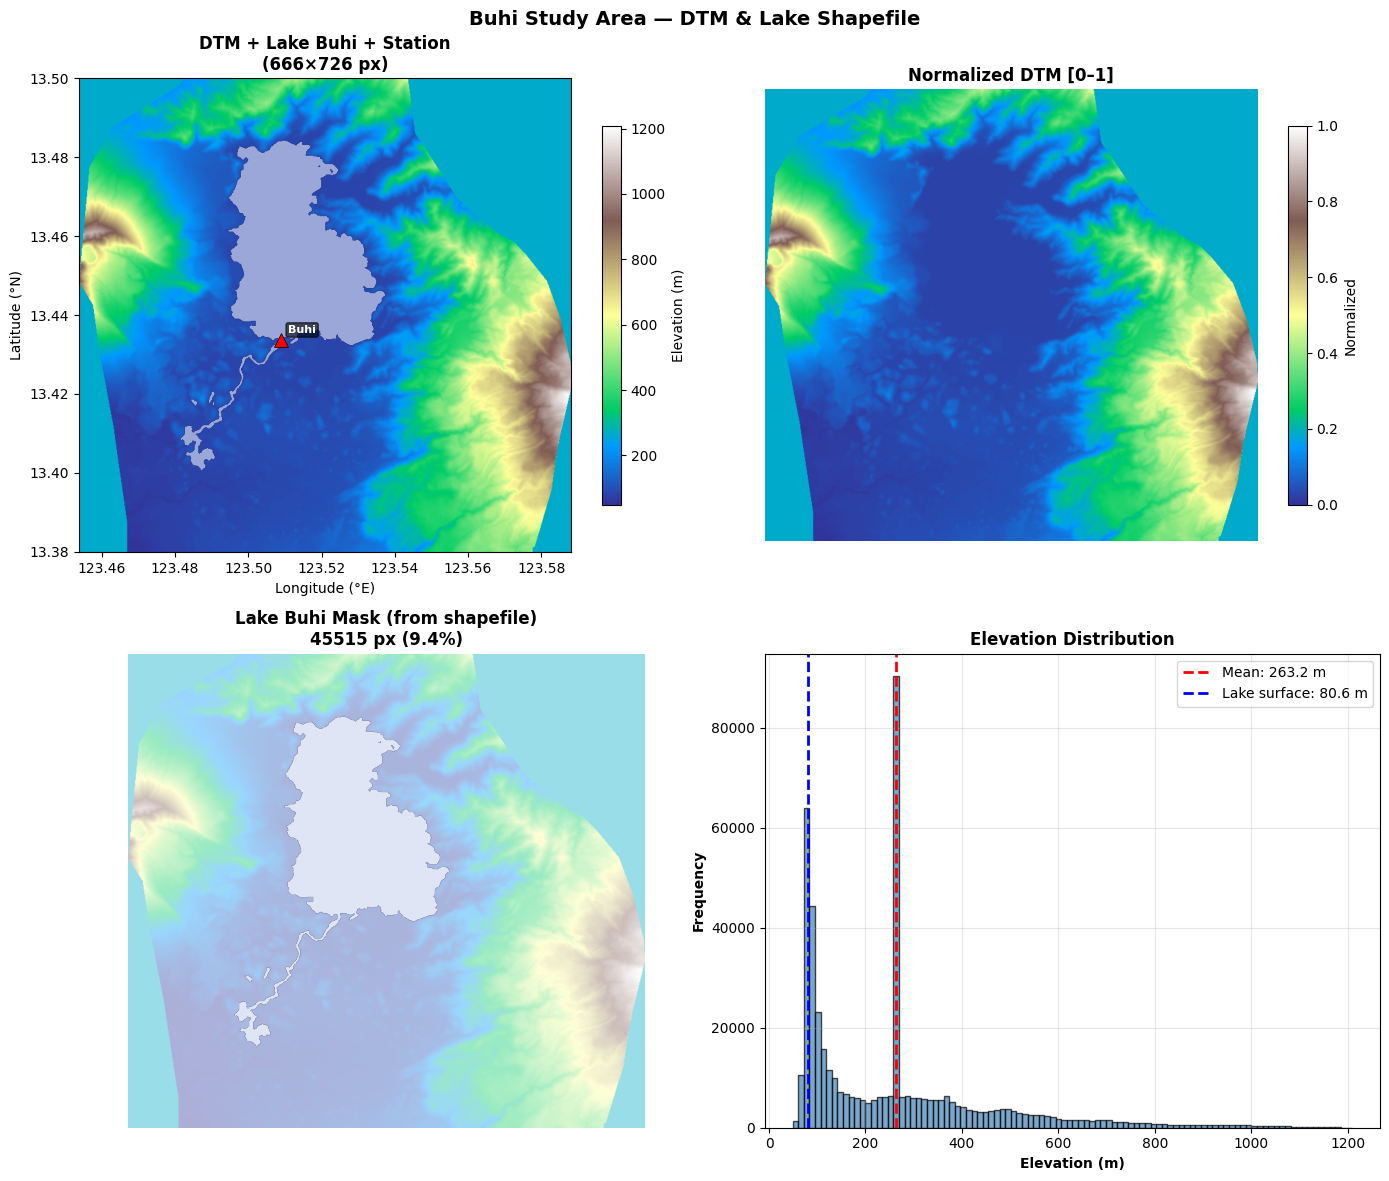


✓ Visualization saved: dem_lake_study_area.png


In [3]:
"""
Cell 3: Load Station Metadata + Clip DTM + Rasterize Lake Shapefile
====================================================================
- Reads station coordinates from BUHI_station_metadata.csv
- Clips BUHI_DTM.tif to the study area
- Rasterizes BUHI_LAKE.shp onto the same grid  → lake_mask
"""

import rasterio
from rasterio.windows import from_bounds
from rasterio.features import rasterize
from pyproj import Transformer, CRS
import geopandas as gpd
import numpy as np
from scipy.ndimage import zoom
import matplotlib.pyplot as plt
import json, gc
from pathlib import Path

print("=" * 70)
print("STATION METADATA + DTM + LAKE SHAPEFILE PROCESSING")
print("=" * 70)

# ── 1. STATION METADATA ─────────────────────────────────────────────────────
print("\n📂 Loading station metadata...")
station_meta_path = Path(CONFIG['STATION_META_CSV'])
if station_meta_path.exists():
    station_df = pd.read_csv(station_meta_path)
    print(f"✓ Station metadata loaded: {station_df.shape}")
    print(station_df.to_string(index=False))

    # Build STATION_COORDS dict from the CSV
    STATION_COORDS = {}
    for _, row in station_df.iterrows():
        # Try common column-name patterns
        name = str(row.get('Station', row.get('station', row.get('Name', row.get('name', 'Buhi')))))
        lat  = float(row.get('Latitude',  row.get('latitude',  row.get('lat', 0))))
        lon  = float(row.get('Longitude', row.get('longitude', row.get('lon', 0))))
        STATION_COORDS[name] = {'lat': lat, 'lon': lon, 'name': f'{name} Station'}

    print(f"\n📍 Stations loaded:")
    for sname, sc in STATION_COORDS.items():
        print(f"   {sname}: {sc['lat']:.5f}°N, {sc['lon']:.4f}°E")
else:
    # Fallback: hardcoded Buhi station coordinates
    print(f"⚠️  {station_meta_path} not found — using hardcoded Buhi coordinates")
    STATION_COORDS = {
        'Buhi': {'lat': 13.4337, 'lon': 123.509, 'name': 'Buhi Station'}
    }

# ── 2. CLIP DTM ─────────────────────────────────────────────────────────────
dem_path = Path(CONFIG['DEM_DTM_PATH'])
DOWNSAMPLE_FACTOR = CONFIG['DOWNSAMPLE_FACTOR']

# Guard against previously corrupted bounds
if CONFIG['STUDY_BOUNDS']['min_lon'] > 180 or CONFIG['STUDY_BOUNDS']['min_lat'] > 90:
    CONFIG['STUDY_BOUNDS'] = {
        'min_lon': 123.40, 'max_lon': 123.60,
        'min_lat': 13.38,  'max_lat': 13.50
    }

bounds_wgs84 = CONFIG['STUDY_BOUNDS'].copy()

if not dem_path.exists():
    raise FileNotFoundError(f"DTM file not found: {dem_path}")

print(f"\n📂 Opening DTM: {dem_path}")

with rasterio.open(dem_path) as src:
    dem_crs = src.crs
    dem_bounds = src.bounds
    res = abs(src.transform[0])

    print(f"\n📊 Original DTM:")
    print(f"   Size: {src.height} × {src.width} = {src.height * src.width:,} px")
    print(f"   CRS:  {dem_crs}")
    print(f"   Bounds: {dem_bounds}")
    print(f"   Resolution: {res:.6f} {'m' if not dem_crs.is_geographic else '°'}/px")

    wgs84 = CRS.from_epsg(4326)
    is_projected = not dem_crs.is_geographic

    if is_projected:
        print(f"\n🔄 Reprojecting WGS84 bounds → DTM CRS...")
        transformer = Transformer.from_crs(wgs84, dem_crs, always_xy=True)
        min_x, min_y = transformer.transform(bounds_wgs84['min_lon'], bounds_wgs84['min_lat'])
        max_x, max_y = transformer.transform(bounds_wgs84['max_lon'], bounds_wgs84['max_lat'])
        clip_left,  clip_bottom = min(min_x, max_x), min(min_y, max_y)
        clip_right, clip_top    = max(min_x, max_x), max(min_y, max_y)
        reverse_transformer = Transformer.from_crs(dem_crs, wgs84, always_xy=True)
    else:
        clip_left   = bounds_wgs84['min_lon']
        clip_bottom = bounds_wgs84['min_lat']
        clip_right  = bounds_wgs84['max_lon']
        clip_top    = bounds_wgs84['max_lat']
        reverse_transformer = None

    # Clamp to DTM extent
    clip_left   = max(clip_left,   dem_bounds.left   + res)
    clip_right  = min(clip_right,  dem_bounds.right  - res)
    clip_bottom = max(clip_bottom, dem_bounds.bottom + res)
    clip_top    = min(clip_top,    dem_bounds.top    - res)

    if clip_left >= clip_right or clip_bottom >= clip_top:
        raise ValueError("Study area does not overlap with DTM!")

    print(f"\n🔧 Clipping to study area...")
    window = from_bounds(clip_left, clip_bottom, clip_right, clip_top, src.transform)
    dem_clipped = src.read(1, window=window).astype(np.float32)
    clipped_transform = src.window_transform(window)
    nodata_val = src.nodata

print(f"\n✓ Clipped DTM: {dem_clipped.shape}")
print(f"   Pixels: {dem_clipped.shape[0] * dem_clipped.shape[1]:,}")
print(f"   Memory: {dem_clipped.nbytes / 1024 / 1024:.1f} MB")

# Handle NoData
if nodata_val is not None:
    invalid = dem_clipped == nodata_val
    if np.any(invalid):
        dem_clipped[invalid] = np.nan
nan_count = np.sum(np.isnan(dem_clipped))
if nan_count > 0:
    fill_val = np.nanmean(dem_clipped)
    dem_clipped = np.nan_to_num(dem_clipped, nan=fill_val)
    print(f"   Filled {nan_count:,} NaN with mean ({fill_val:.1f} m)")

# Downsample
if DOWNSAMPLE_FACTOR > 1:
    print(f"\n🔧 Downsampling {DOWNSAMPLE_FACTOR}×...")
    orig_shape = dem_clipped.shape
    dem_processed = zoom(dem_clipped, 1.0 / DOWNSAMPLE_FACTOR, order=1)
    print(f"   {orig_shape} → {dem_processed.shape}")
    new_transform = clipped_transform * clipped_transform.scale(DOWNSAMPLE_FACTOR,
                                                                  DOWNSAMPLE_FACTOR)
else:
    dem_processed = dem_clipped
    new_transform = clipped_transform

height, width = dem_processed.shape
dem_min = float(dem_processed.min())
dem_max = float(dem_processed.max())
dem_mean = float(dem_processed.mean())
dem_std  = float(dem_processed.std())

print(f"\n📊 Processed DTM Statistics:")
print(f"   Shape: {dem_processed.shape}")
print(f"   Elevation: {dem_min:.2f} – {dem_max:.2f} m  (mean {dem_mean:.2f}, σ {dem_std:.2f})")
print(f"   Memory: {dem_processed.nbytes / 1024 / 1024:.2f} MB")

# Normalize
dem_norm = ((dem_processed - dem_min) / (dem_max - dem_min + 1e-8)).astype(np.float32)

# Low-lying mask
low_threshold = np.percentile(dem_processed, 25)
lowlying_mask = (dem_processed <= low_threshold).astype(np.float32)
print(f"\n🌊 Low-lying (≤{low_threshold:.1f} m): {100 * np.mean(lowlying_mask):.1f}%")

# ── 3. RASTERIZE LAKE SHAPEFILE ─────────────────────────────────────────────
lake_path = Path(CONFIG['LAKE_SHAPEFILE'])
if not lake_path.exists():
    raise FileNotFoundError(f"Lake shapefile not found: {lake_path}")

print(f"\n📂 Loading lake shapefile: {lake_path}")
import os
os.environ['SHAPE_RESTORE_SHX'] = 'YES'   # auto-create .shx if missing
lake_gdf = gpd.read_file(lake_path)
print(f"   CRS: {lake_gdf.crs}")
print(f"   Features: {len(lake_gdf)}")
print(f"   Total area: {lake_gdf.geometry.area.sum():.2f} (in CRS units)")

# Reproject lake to match DTM CRS
if lake_gdf.crs is not None and str(lake_gdf.crs) != str(dem_crs):
    print(f"   Reprojecting lake {lake_gdf.crs} → {dem_crs}")
    lake_gdf = lake_gdf.to_crs(dem_crs)

# Rasterize onto the processed (downsampled) DTM grid
lake_shapes = [(geom, 1) for geom in lake_gdf.geometry if geom is not None]
lake_mask = rasterize(
    lake_shapes,
    out_shape=dem_processed.shape,
    transform=new_transform,
    fill=0,
    dtype=np.uint8,
    all_touched=True
).astype(np.float32)

lake_pixels = int(lake_mask.sum())
lake_pct = 100 * lake_pixels / dem_processed.size
print(f"\n✓ Lake mask rasterized: {lake_pixels} px ({lake_pct:.1f}% of grid)")

# Derive lake-surface elevation from the DTM pixels under the lake mask
lake_elevations = dem_processed[lake_mask > 0]
if len(lake_elevations) > 0:
    lake_surface_elev = float(np.median(lake_elevations))
    lake_bank_elev    = float(np.percentile(lake_elevations, 95))
else:
    lake_surface_elev = dem_mean
    lake_bank_elev    = dem_mean
print(f"   Lake surface elevation (median): {lake_surface_elev:.2f} m")
print(f"   Lake bank elevation (P95):       {lake_bank_elev:.2f} m")

# ── 4. STATION PIXEL LOCATIONS ──────────────────────────────────────────────
if is_projected:
    proj_transformer = Transformer.from_crs(wgs84, dem_crs, always_xy=True)

station_pixels = {}
print(f"\n📍 Station pixel locations:")
for area, coords in STATION_COORDS.items():
    if is_projected:
        sx, sy = proj_transformer.transform(coords['lon'], coords['lat'])
    else:
        sx, sy = coords['lon'], coords['lat']

    if clip_left <= sx <= clip_right and clip_bottom <= sy <= clip_top:
        inv_t = ~new_transform
        col_f, row_f = inv_t * (sx, sy)
        col = int(np.clip(col_f, 0, width - 1))
        row = int(np.clip(row_f, 0, height - 1))
        elev = dem_processed[row, col]
        station_pixels[area] = {'row': row, 'col': col}
        print(f"   {area}: pixel ({row}, {col}), elev {elev:.1f} m")
    else:
        print(f"   ⚠️ {area} is outside clipped DTM")

# ── 5. SAVE EVERYTHING ──────────────────────────────────────────────────────
np.save('dem_processed.npy', dem_processed)
np.save('dem_normalized.npy', dem_norm)
np.save('lowlying_mask.npy', lowlying_mask)
np.save('lake_mask.npy', lake_mask)

# For display extent in later plots
if is_projected and reverse_transformer is not None:
    lon_bl, lat_bl = reverse_transformer.transform(clip_left, clip_bottom)
    lon_tr, lat_tr = reverse_transformer.transform(clip_right, clip_top)
    display_extent = [lon_bl, lon_tr, lat_bl, lat_tr]
else:
    display_extent = [clip_left, clip_right, clip_bottom, clip_top]

dem_metadata = {
    'original_file':      str(dem_path),
    'processed_shape':    list(dem_processed.shape),
    'downsample_factor':  DOWNSAMPLE_FACTOR,
    'dem_crs':            str(dem_crs),
    'study_bounds_wgs84': bounds_wgs84,
    'clip_bounds_native': {
        'left': clip_left, 'right': clip_right,
        'bottom': clip_bottom, 'top': clip_top
    },
    'transform':          list(new_transform)[:6],
    'display_extent':     display_extent,
    'statistics': {
        'min': dem_min, 'max': dem_max,
        'mean': dem_mean, 'std': dem_std
    },
    'lake': {
        'shapefile':        str(lake_path),
        'pixels':           lake_pixels,
        'surface_elev':     lake_surface_elev,
        'bank_elev':        lake_bank_elev,
    },
    'station_pixels': station_pixels,
}

with open('dem_metadata.json', 'w') as f:
    json.dump(dem_metadata, f, indent=2)

print("\n💾 Saved: dem_processed.npy, dem_normalized.npy, lowlying_mask.npy,")
print("         lake_mask.npy, dem_metadata.json")

# ── 6. VISUALIZATION ────────────────────────────────────────────────────────
print("\n📊 Creating visualization...")
xlabel, ylabel = 'Longitude (°E)', 'Latitude (°N)'
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# (a) DTM with station + lake overlay
ax1 = axes[0, 0]
im1 = ax1.imshow(dem_processed, cmap='terrain', extent=display_extent, aspect='auto')
lake_vis = np.ma.masked_where(lake_mask == 0, lake_mask)
ax1.imshow(lake_vis, cmap='Blues', alpha=0.55, extent=display_extent, aspect='auto')
for area, coords in STATION_COORDS.items():
    ax1.plot(coords['lon'], coords['lat'], 'r^', markersize=10,
             markeredgecolor='black', markeredgewidth=0.5)
    ax1.annotate(area, (coords['lon'], coords['lat']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8,
                 fontweight='bold', color='white',
                 bbox=dict(boxstyle='round,pad=0.2', fc='black', alpha=0.6))
ax1.set_xlabel(xlabel); ax1.set_ylabel(ylabel)
ax1.set_title(f'DTM + Lake Buhi + Station\n({height}×{width} px)', fontweight='bold')
plt.colorbar(im1, ax=ax1, label='Elevation (m)', shrink=0.8)

# (b) Normalized DTM
ax2 = axes[0, 1]
im2 = ax2.imshow(dem_norm, cmap='terrain', vmin=0, vmax=1)
ax2.set_title('Normalized DTM [0–1]', fontweight='bold'); ax2.axis('off')
plt.colorbar(im2, ax=ax2, label='Normalized', shrink=0.8)

# (c) Lake mask
ax3 = axes[1, 0]
ax3.imshow(dem_processed, cmap='terrain', alpha=0.4)
ax3.imshow(np.ma.masked_where(lake_mask == 0, lake_mask), cmap='Blues', alpha=0.7)
ax3.set_title(f'Lake Buhi Mask (from shapefile)\n{lake_pixels} px ({lake_pct:.1f}%)',
              fontweight='bold'); ax3.axis('off')

# (d) Elevation histogram
ax4 = axes[1, 1]
ax4.hist(dem_processed.flatten(), bins=100, color='steelblue', alpha=0.7, edgecolor='black')
ax4.axvline(dem_mean, color='red', ls='--', lw=2, label=f'Mean: {dem_mean:.1f} m')
ax4.axvline(lake_surface_elev, color='blue', ls='--', lw=2,
            label=f'Lake surface: {lake_surface_elev:.1f} m')
ax4.set_xlabel('Elevation (m)', fontweight='bold')
ax4.set_ylabel('Frequency', fontweight='bold')
ax4.set_title('Elevation Distribution', fontweight='bold')
ax4.legend(); ax4.grid(True, alpha=0.3)

plt.suptitle('Buhi Study Area — DTM & Lake Shapefile', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('dem_lake_study_area.png', dpi=150, bbox_inches='tight')
plt.show()

del dem_clipped; gc.collect()
print("\n✓ Visualization saved: dem_lake_study_area.png")
print("=" * 70)

## Step 3: Rainfall & River Level Data Preprocessing

- Loads `BUHI_Rainfall-Data.csv` and `BUHI_Riverlevel-Data.csv`
- Handles missing values (forward/backward fill)
- Normalizes to [0, 1] for neural-network training
- Saves normalization parameters for later de-normalization
- Creates time-series visualizations with warning thresholds

RAINFALL & RIVER LEVEL DATA PREPROCESSING

📂 Loading data files...
✓ Rainfall:    (65535, 2)
✓ River level: (9008, 255)
✓ Time column: 'TimeDate'

📊 Rainfall columns:    ['Buhi']
   River level columns: ['Buhi']

🔧 Parsing DateTime...
✓ Rainfall:    2024-10-19 01:00:00 → 2025-10-29 08:00:00  (9,008 rows)
✓ River level: 2024-10-19 01:00:00 → 2025-10-29 08:00:00  (9,008 rows)

🔧 Handling missing values...
   Missing (rainfall):    {'Buhi': np.int64(148)}
   Missing (river level): {'Buhi': np.int64(98)}
✓ Filled (ffill → bfill → fallback)

📊 Ranges:
   Rainfall:    0.00 – 78.00 mm
   River level: 0.00 – 3.15 m
✓ Saved: rainfall_normalized.csv, riverlevel_normalized.csv, normalization_params.json

📊 Creating visualization...


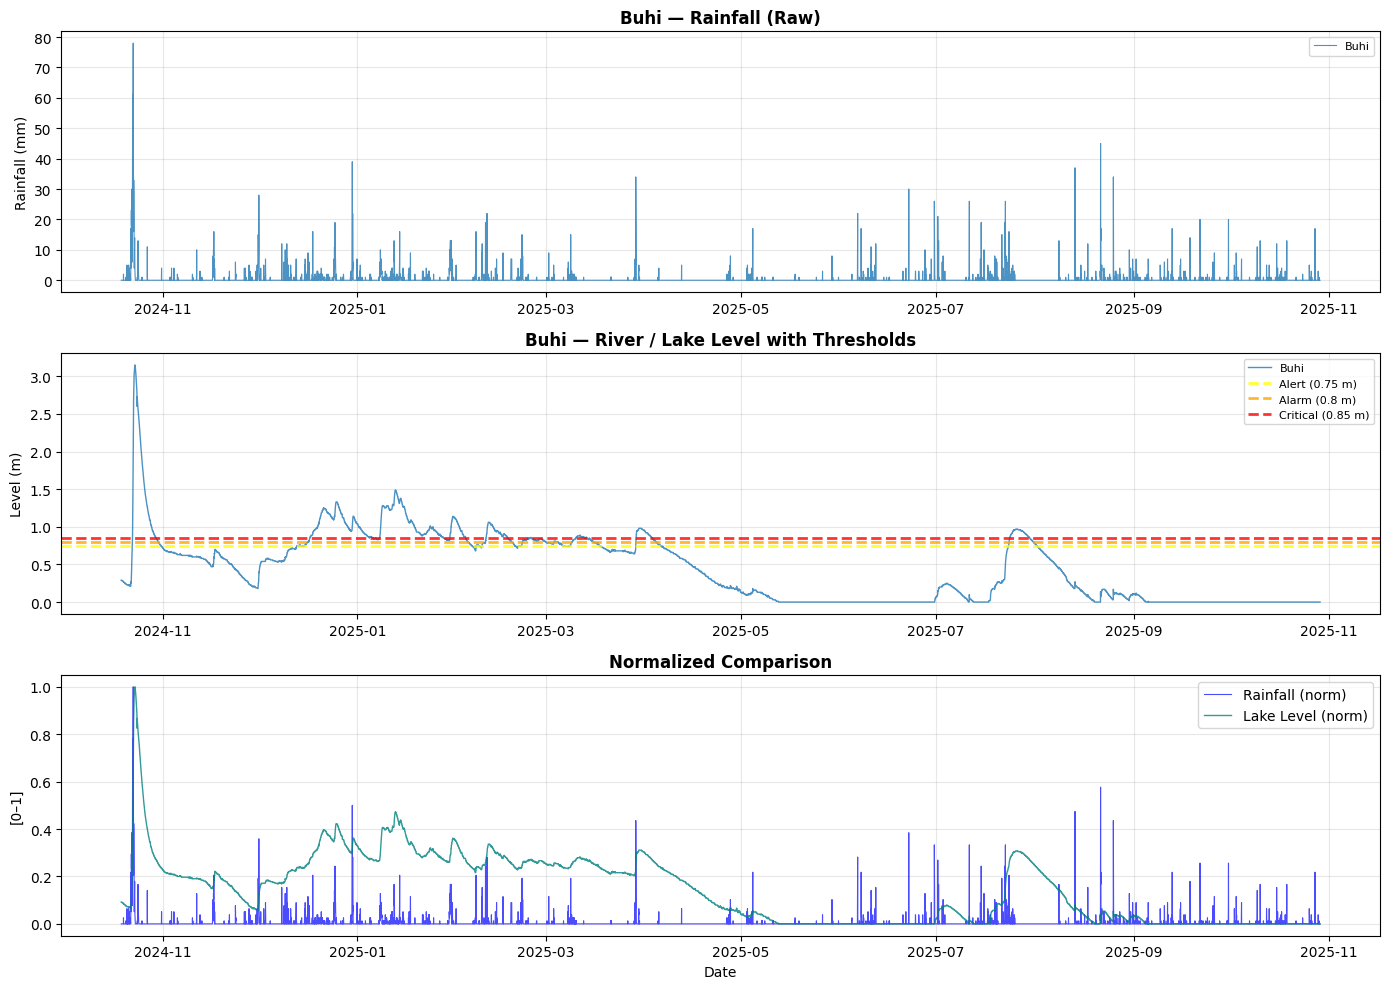


📊 Threshold Exceedance Analysis:
   Alert (≥0.75 m): 2,759 hours
   Alarm (≥0.8 m): 2,315 hours
   Critical (≥0.85 m): 1,841 hours

✓ Saved: timeseries_visualization.png


In [5]:
"""
Cell 4: Rainfall & River Level Data Preprocessing
==================================================
Buhi single-station: load, clean, normalize
"""

import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import json

print("=" * 70)
print("RAINFALL & RIVER LEVEL DATA PREPROCESSING")
print("=" * 70)

# ── Load CSVs ────────────────────────────────────────────────────────────────
print("\n📂 Loading data files...")

try:
    rainfall_df   = pd.read_csv(CONFIG['RAINFALL_CSV'],
                                na_values=['NaN', 'nan', 'NAN', '', '-'])
    riverlevel_df = pd.read_csv(CONFIG['RIVERLEVEL_CSV'],
                                na_values=['NaN', 'nan', 'NAN', '', '-'])
    print(f"✓ Rainfall:    {rainfall_df.shape}")
    print(f"✓ River level: {riverlevel_df.shape}")
except FileNotFoundError as e:
    raise FileNotFoundError(f"Data file not found: {e}")

# Drop stray blank columns from Excel export
riverlevel_df = riverlevel_df.loc[:, ~riverlevel_df.columns.str.startswith('Unnamed')]
rainfall_df   = rainfall_df.loc[:,   ~rainfall_df.columns.str.startswith('Unnamed')]

# Detect datetime column
time_col = None
for candidate in ['TimeDate', 'DateTime', 'datetime', 'Date', 'date', 'Timestamp']:
    if candidate in rainfall_df.columns:
        time_col = candidate
        break
if time_col is None:
    time_col = rainfall_df.columns[0]
    print(f"⚠️  Using first column as datetime: '{time_col}'")
else:
    print(f"✓ Time column: '{time_col}'")

# Data columns (everything except the datetime column)
rain_cols  = [c for c in rainfall_df.columns   if c != time_col]
river_cols = [c for c in riverlevel_df.columns  if c != time_col]
print(f"\n📊 Rainfall columns:    {rain_cols}")
print(f"   River level columns: {river_cols}")

# Parse datetime
print("\n🔧 Parsing DateTime...")
rainfall_df[time_col]   = pd.to_datetime(rainfall_df[time_col],
                                          format='%Y-%m-%d %H', errors='coerce')
riverlevel_df[time_col] = pd.to_datetime(riverlevel_df[time_col],
                                          format='%Y-%m-%d %H', errors='coerce')

rainfall_df   = rainfall_df.set_index(time_col).sort_index().loc[lambda d: d.index.notna()]
riverlevel_df = riverlevel_df.set_index(time_col).sort_index().loc[lambda d: d.index.notna()]

print(f"✓ Rainfall:    {rainfall_df.index.min()} → {rainfall_df.index.max()}  "
      f"({len(rainfall_df):,} rows)")
print(f"✓ River level: {riverlevel_df.index.min()} → {riverlevel_df.index.max()}  "
      f"({len(riverlevel_df):,} rows)")

# ── Missing values ───────────────────────────────────────────────────────────
print("\n🔧 Handling missing values...")
print(f"   Missing (rainfall):    {dict(rainfall_df.isna().sum())}")
print(f"   Missing (river level): {dict(riverlevel_df.isna().sum())}")

rainfall_df   = rainfall_df.apply(pd.to_numeric, errors='coerce')
riverlevel_df = riverlevel_df.apply(pd.to_numeric, errors='coerce')

rainfall_df   = rainfall_df.ffill().bfill().fillna(0)
riverlevel_df = riverlevel_df.ffill().bfill().fillna(riverlevel_df.mean())
print("✓ Filled (ffill → bfill → fallback)")

# ── Normalization ────────────────────────────────────────────────────────────
rain_min  = float(rainfall_df.min().min())
rain_max  = float(rainfall_df.max().max())
river_min = float(riverlevel_df.min().min())
river_max = float(riverlevel_df.max().max())

print(f"\n📊 Ranges:")
print(f"   Rainfall:    {rain_min:.2f} – {rain_max:.2f} mm")
print(f"   River level: {river_min:.2f} – {river_max:.2f} m")

rain_scaler  = MinMaxScaler()
river_scaler = MinMaxScaler()

rainfall_norm = pd.DataFrame(
    rain_scaler.fit_transform(rainfall_df),
    index=rainfall_df.index, columns=rainfall_df.columns)
riverlevel_norm = pd.DataFrame(
    river_scaler.fit_transform(riverlevel_df),
    index=riverlevel_df.index, columns=riverlevel_df.columns)

rainfall_norm.to_csv('rainfall_normalized.csv')
riverlevel_norm.to_csv('riverlevel_normalized.csv')

norm_params = {
    'rainfall':   {'min': rain_min,  'max': rain_max},
    'riverlevel': {'min': river_min, 'max': river_max},
    'thresholds': CONFIG['THRESHOLDS'],
    'thresholds_normalized': {
        k: (v - river_min) / (river_max - river_min) if river_max > river_min else 0
        for k, v in CONFIG['THRESHOLDS'].items()
    }
}
with open('normalization_params.json', 'w') as f:
    json.dump(norm_params, f, indent=2)

print("✓ Saved: rainfall_normalized.csv, riverlevel_normalized.csv, normalization_params.json")

# ── Visualization ────────────────────────────────────────────────────────────
print("\n📊 Creating visualization...")
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Rainfall
ax1 = axes[0]
for col in rainfall_df.columns:
    ax1.plot(rainfall_df.index, rainfall_df[col], lw=0.8, alpha=0.8, label=col)
ax1.set_title('Buhi — Rainfall (Raw)', fontweight='bold')
ax1.set_ylabel('Rainfall (mm)'); ax1.legend(loc='upper right', fontsize=8)
ax1.grid(True, alpha=0.3)

# River level with thresholds
ax2 = axes[1]
for col in riverlevel_df.columns:
    ax2.plot(riverlevel_df.index, riverlevel_df[col], lw=1, alpha=0.8, label=col)
for tname, tval in CONFIG['THRESHOLDS'].items():
    if tname != 'normal':
        color = {'alert': 'yellow', 'alarm': 'orange', 'critical': 'red'}[tname]
        ax2.axhline(y=tval, color=color, ls='--', lw=2, alpha=0.8,
                    label=f"{tname.capitalize()} ({tval} m)")
ax2.set_title('Buhi — River / Lake Level with Thresholds', fontweight='bold')
ax2.set_ylabel('Level (m)'); ax2.legend(loc='upper right', fontsize=8)
ax2.grid(True, alpha=0.3)

# Normalized comparison
ax3 = axes[2]
ax3.plot(rainfall_norm.index,   rainfall_norm.iloc[:, 0],
         color='blue', lw=0.8, alpha=0.7, label=f'Rainfall (norm)')
ax3.plot(riverlevel_norm.index, riverlevel_norm.iloc[:, 0],
         color='teal', lw=1, alpha=0.8, label=f'Lake Level (norm)')
ax3.set_title('Normalized Comparison', fontweight='bold')
ax3.set_xlabel('Date'); ax3.set_ylabel('[0–1]')
ax3.legend(); ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('timeseries_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

# Threshold exceedances
print("\n📊 Threshold Exceedance Analysis:")
for tname, tval in CONFIG['THRESHOLDS'].items():
    if tname != 'normal':
        exc = (riverlevel_df >= tval).sum().sum()
        print(f"   {tname.capitalize()} (≥{tval} m): {exc:,} hours")

print("\n✓ Saved: timeseries_visualization.png")
print("=" * 70)

## Step 4: Create Spatial-Temporal Data Grid

Builds a 4-channel spatial grid for every timestep:

| Channel | Content | Type |
|---------|---------|------|
| 0 | Rainfall | Time-varying (broadcast from Buhi station) |
| 1 | Lake Level | Time-varying (broadcast from Buhi station) |
| 2 | DTM (normalized) | Static terrain |
| 3 | **Lake mask** (from shapefile) | Static — defines the overflow boundary |

The **lake mask** replaces the old low-lying heuristic.  It tells the model *exactly*
where the lake is, so flood estimation later starts from the true lake boundary.

SPATIAL-TEMPORAL DATA GENERATION

📐 Target grid: 128×128

📂 Loading normalized time series...
✓ Timesteps: 9,008
   Rainfall  [0.0000, 1.0000]
   Lake level [0.0000, 1.0000]

📂 Resizing DTM & lake mask to 128×128...
   DTM  shape: (128, 128), range 54.1–1198.3 m
   Lake mask:  1517 px (9.3%)

💾 Spatial data:
   Shape: (9008, 128, 128, 4)
   Size:  2252.0 MB
   Fits in RAM

⏳ Filling 9,008 frames...
   ✓ All 9,008 frames filled

✓ Saved: spatial_data.npy (2252.0 MB)

📊 Channel Statistics:
   Ch0 (Rainfall): [0.0000, 1.0000]
   Ch1 (Lake Level): [0.0000, 1.0000]
   Ch2 (DTM): [0.0000, 1.0000]
   Ch3 (Lake Mask): [0.0000, 1.0000]


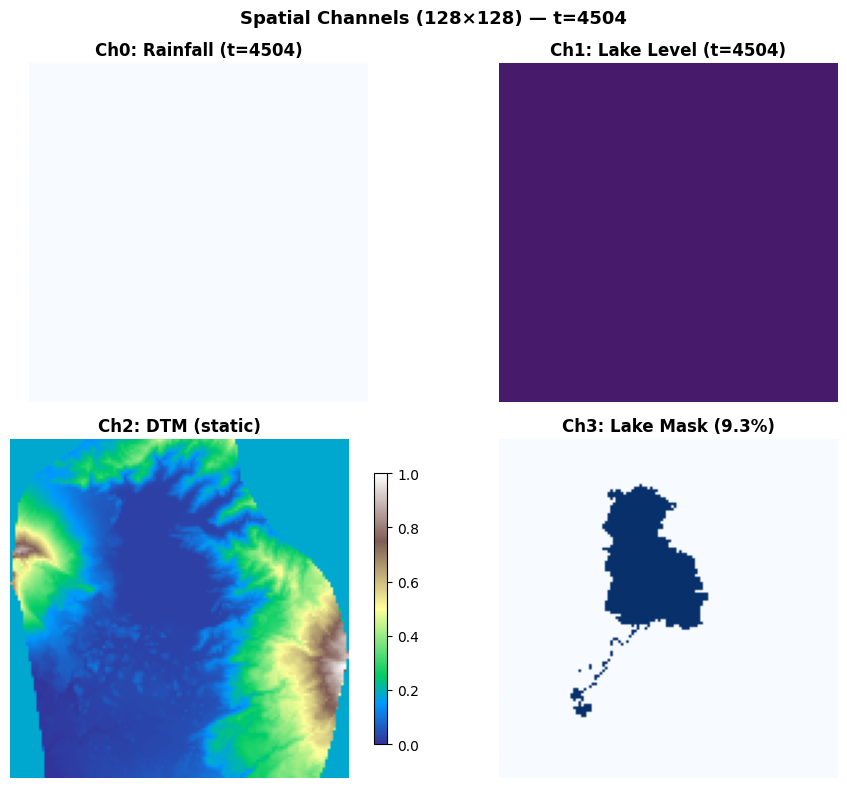


✓ Saved: spatial_data_channels.png


In [6]:
"""
Cell 5: Create Spatial-Temporal Data Grid (Memory Efficient)
============================================================
128×128 grid — 4 channels: Rainfall | Lake Level | DTM | Lake Mask
"""

import numpy as np
import pandas as pd
from scipy.ndimage import zoom
import json
from pathlib import Path
import matplotlib.pyplot as plt
import gc

print("=" * 70)
print("SPATIAL-TEMPORAL DATA GENERATION")
print("=" * 70)

# ── Target grid size ──
GRID_SIZE = 128
print(f"\n📐 Target grid: {GRID_SIZE}×{GRID_SIZE}")

# ── Load normalized time series ──
print("\n📂 Loading normalized time series...")
rainfall_norm   = pd.read_csv('rainfall_normalized.csv',   index_col=0, parse_dates=True)
riverlevel_norm = pd.read_csv('riverlevel_normalized.csv', index_col=0, parse_dates=True)

# Use the first (or only) column for the Buhi station
rainfall_values   = rainfall_norm.iloc[:, 0].values.astype(np.float32)
riverlevel_values = riverlevel_norm.iloc[:, 0].values.astype(np.float32)
n_timesteps = len(rainfall_values)

print(f"✓ Timesteps: {n_timesteps:,}")
print(f"   Rainfall  [{rainfall_values.min():.4f}, {rainfall_values.max():.4f}]")
print(f"   Lake level [{riverlevel_values.min():.4f}, {riverlevel_values.max():.4f}]")

# ── Load DTM + lake mask and resize to GRID_SIZE ──
print(f"\n📂 Resizing DTM & lake mask to {GRID_SIZE}×{GRID_SIZE}...")
dem_processed = np.load('dem_processed.npy')
lake_mask_full = np.load('lake_mask.npy')

zoom_h = GRID_SIZE / dem_processed.shape[0]
zoom_w = GRID_SIZE / dem_processed.shape[1]

dem_small = zoom(dem_processed, (zoom_h, zoom_w), order=1).astype(np.float32)
dem_min, dem_max = dem_small.min(), dem_small.max()
dem_small_norm = ((dem_small - dem_min) / (dem_max - dem_min + 1e-8)).astype(np.float32)

# Lake mask — nearest-neighbor interpolation to preserve binary values
lake_small = zoom(lake_mask_full, (zoom_h, zoom_w), order=0).astype(np.float32)
lake_small = (lake_small > 0.5).astype(np.float32)  # re-binarize

lake_pct = 100 * np.mean(lake_small)
print(f"   DTM  shape: {dem_small_norm.shape}, range {dem_min:.1f}–{dem_max:.1f} m")
print(f"   Lake mask:  {int(lake_small.sum())} px ({lake_pct:.1f}%)")

del dem_processed, lake_mask_full; gc.collect()

# ── Build spatial-temporal array ──
n_channels = 4
total_bytes = n_timesteps * GRID_SIZE * GRID_SIZE * n_channels * 4
total_mb = total_bytes / (1024**2)

print(f"\n💾 Spatial data:")
print(f"   Shape: ({n_timesteps}, {GRID_SIZE}, {GRID_SIZE}, {n_channels})")
print(f"   Size:  {total_mb:.1f} MB")

if total_mb > 4000:
    print("   Using memory-mapped file")
    f_name = 'spatial_data.npy'
    if Path(f_name).exists():
        Path(f_name).unlink()
    spatial_data = np.lib.format.open_memmap(
        f_name, mode='w+', dtype=np.float32,
        shape=(n_timesteps, GRID_SIZE, GRID_SIZE, n_channels))
else:
    print("   Fits in RAM")
    spatial_data = np.zeros(
        (n_timesteps, GRID_SIZE, GRID_SIZE, n_channels), dtype=np.float32)

# Static channels (2 = DTM, 3 = lake mask)
spatial_data[:, :, :, 2] = dem_small_norm[np.newaxis, :, :]
spatial_data[:, :, :, 3] = lake_small[np.newaxis, :, :]

# Time-varying channels
print(f"\n⏳ Filling {n_timesteps:,} frames...")
for t in range(n_timesteps):
    spatial_data[t, :, :, 0] = rainfall_values[t]
    spatial_data[t, :, :, 1] = riverlevel_values[t]
    if (t + 1) % 5000 == 0:
        print(f"   {t+1:,}/{n_timesteps:,}...", end='\r')
print(f"   ✓ All {n_timesteps:,} frames filled")

# Save
if isinstance(spatial_data, np.memmap):
    spatial_data.flush()
else:
    np.save('spatial_data.npy', spatial_data)
print(f"\n✓ Saved: spatial_data.npy ({total_mb:.1f} MB)")

np.save('dem_small_norm.npy', dem_small_norm)
np.save('dem_small.npy', dem_small)
np.save('lake_small.npy', lake_small)

# Channel stats
print("\n📊 Channel Statistics:")
for ch, name in enumerate(['Rainfall', 'Lake Level', 'DTM', 'Lake Mask']):
    cd = spatial_data[:, :, :, ch]
    print(f"   Ch{ch} ({name}): [{cd.min():.4f}, {cd.max():.4f}]")

# ── Visualization ──
sample_t = n_timesteps // 2
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(spatial_data[sample_t, :, :, 0], cmap='Blues', vmin=0, vmax=1)
axes[0, 0].set_title(f'Ch0: Rainfall (t={sample_t})', fontweight='bold'); axes[0, 0].axis('off')

axes[0, 1].imshow(spatial_data[sample_t, :, :, 1], cmap='viridis', vmin=0, vmax=1)
axes[0, 1].set_title(f'Ch1: Lake Level (t={sample_t})', fontweight='bold'); axes[0, 1].axis('off')

im2 = axes[1, 0].imshow(spatial_data[sample_t, :, :, 2], cmap='terrain')
axes[1, 0].set_title('Ch2: DTM (static)', fontweight='bold'); axes[1, 0].axis('off')
plt.colorbar(im2, ax=axes[1, 0], shrink=0.8)

axes[1, 1].imshow(spatial_data[sample_t, :, :, 3], cmap='Blues')
axes[1, 1].set_title(f'Ch3: Lake Mask ({lake_pct:.1f}%)', fontweight='bold'); axes[1, 1].axis('off')

plt.suptitle(f'Spatial Channels ({GRID_SIZE}×{GRID_SIZE}) — t={sample_t}',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('spatial_data_channels.png', dpi=150, bbox_inches='tight')
plt.show()

del spatial_data; gc.collect()
print(f"\n✓ Saved: spatial_data_channels.png")
print("=" * 70)

## Step 5: Sequence Generation for Training

Creates training sequences:
- **Input**: 12 hours of (rainfall, lake level, DTM, lake mask) → 4 channels
- **Output**: 6 hours of future **lake levels** (single channel)

The model learns: *given recent rainfall + current lake level + terrain + lake geometry,
predict how the lake level will change over the next 6 hours.*

In [7]:
"""
Cell 6: Sequence Generation for ConvLSTM Training
==================================================
12-hour input → 6-hour output, memory-mapped
"""

import numpy as np
from pathlib import Path
import json, gc

print("=" * 70)
print("SEQUENCE GENERATION FOR TRAINING")
print("=" * 70)

INPUT_HOURS  = CONFIG['INPUT_HOURS']   # 12
OUTPUT_HOURS = CONFIG['OUTPUT_HOURS']  # 6
STRIDE       = 6
TRAIN_SPLIT  = 0.8

# Load spatial data (memory-mapped)
print("\n📂 Loading spatial data...")
spatial_data = np.load('spatial_data.npy', mmap_mode='r')
total_timesteps, height, width, n_channels = spatial_data.shape

print(f"✓ Shape: {spatial_data.shape}")

total_seq_len = INPUT_HOURS + OUTPUT_HOURS
max_start = total_timesteps - total_seq_len
n_sequences = (max_start // STRIDE) + 1
n_train = int(n_sequences * TRAIN_SPLIT)
n_test  = n_sequences - n_train

print(f"\n📊 Sequences:")
print(f"   Input: {INPUT_HOURS}h | Output: {OUTPUT_HOURS}h | Stride: {STRIDE}")
print(f"   Total: {n_sequences:,} | Train: {n_train:,} | Test: {n_test:,}")

# Memory estimation
est_gb = (n_sequences * (INPUT_HOURS * n_channels + OUTPUT_HOURS * 1)
          * height * width * 4) / 1024**3
print(f"\n💾 Estimated total: {est_gb:.2f} GB")

# Clean up old files
print("\n🔧 Creating sequence files...")
for fname in ['X_train.npy', 'Y_train.npy', 'X_test.npy', 'Y_test.npy']:
    if Path(fname).exists():
        try:
            Path(fname).unlink()
        except PermissionError:
            print(f"   ⚠️ {fname} locked — will overwrite")
gc.collect()

X_train = np.lib.format.open_memmap(
    'X_train.npy', mode='w+', dtype=np.float32,
    shape=(n_train, INPUT_HOURS, height, width, n_channels))
Y_train = np.lib.format.open_memmap(
    'Y_train.npy', mode='w+', dtype=np.float32,
    shape=(n_train, OUTPUT_HOURS, height, width, 1))
X_test = np.lib.format.open_memmap(
    'X_test.npy', mode='w+', dtype=np.float32,
    shape=(n_test, INPUT_HOURS, height, width, n_channels))
Y_test = np.lib.format.open_memmap(
    'Y_test.npy', mode='w+', dtype=np.float32,
    shape=(n_test, OUTPUT_HOURS, height, width, 1))

print(f"✓ X_train: {X_train.shape}  Y_train: {Y_train.shape}")
print(f"  X_test:  {X_test.shape}   Y_test:  {Y_test.shape}")

# Fill training sequences
print("\n⏳ Generating training sequences...")
for i in range(n_train):
    s = i * STRIDE
    X_train[i] = spatial_data[s : s + INPUT_HOURS]
    Y_train[i] = spatial_data[s + INPUT_HOURS : s + INPUT_HOURS + OUTPUT_HOURS, :, :, 1:2]
    if (i + 1) % 200 == 0 or i == n_train - 1:
        print(f"   {i+1}/{n_train}", end='\r')
print(f"\n✓ Training done")

print("⏳ Generating test sequences...")
for i in range(n_test):
    s = (n_train + i) * STRIDE
    X_test[i] = spatial_data[s : s + INPUT_HOURS]
    Y_test[i] = spatial_data[s + INPUT_HOURS : s + INPUT_HOURS + OUTPUT_HOURS, :, :, 1:2]
    if (i + 1) % 200 == 0 or i == n_test - 1:
        print(f"   {i+1}/{n_test}", end='\r')
print(f"\n✓ Test done")

X_train.flush(); Y_train.flush(); X_test.flush(); Y_test.flush()

seq_metadata = {
    'input_hours':  INPUT_HOURS,
    'output_hours': OUTPUT_HOURS,
    'stride':       STRIDE,
    'n_train':      n_train,
    'n_test':       n_test,
    'grid_height':  height,
    'grid_width':   width,
    'input_shape':  list(X_train.shape[1:]),
    'output_shape': list(Y_train.shape[1:]),
    'channels':     ['rainfall', 'lake_level', 'dtm', 'lake_mask']
}
with open('sequence_metadata.json', 'w') as f:
    json.dump(seq_metadata, f, indent=2)

del X_train, Y_train, X_test, Y_test, spatial_data; gc.collect()
print("\n✓ Saved: X_train/Y_train/X_test/Y_test .npy, sequence_metadata.json")
print("=" * 70)

SEQUENCE GENERATION FOR TRAINING

📂 Loading spatial data...
✓ Shape: (9008, 128, 128, 4)

📊 Sequences:
   Input: 12h | Output: 6h | Stride: 6
   Total: 1,499 | Train: 1,199 | Test: 300

💾 Estimated total: 4.94 GB

🔧 Creating sequence files...
✓ X_train: (1199, 12, 128, 128, 4)  Y_train: (1199, 6, 128, 128, 1)
  X_test:  (300, 12, 128, 128, 4)   Y_test:  (300, 6, 128, 128, 1)

⏳ Generating training sequences...
   1199/1199
✓ Training done
⏳ Generating test sequences...
   300/300
✓ Test done

✓ Saved: X_train/Y_train/X_test/Y_test .npy, sequence_metadata.json


## Step 6: ConvLSTM Model Architecture

Lightweight ConvLSTM optimized for RTX 3050Ti (4 GB VRAM):
- Adaptive filter counts based on grid size
- L2 regularization + dropout to combat overfitting
- Output: single channel (lake level) for the next 6 hours

In [8]:
"""
Cell 7: ConvLSTM Model Definition
==================================
Lightweight architecture for RTX 3050Ti (4 GB VRAM)
"""

import tensorflow as tf
from tensorflow.keras import layers, Model
import json, numpy as np

print("=" * 70)
print("CONVLSTM MODEL DEFINITION")
print("=" * 70)

# Threading
try:
    tf.config.threading.set_intra_op_parallelism_threads(4)
    tf.config.threading.set_inter_op_parallelism_threads(4)
except: pass

# GPU config
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✓ GPU memory growth enabled ({len(gpus)} GPU)")
    except Exception as e:
        print(f"⚠️ {e}")

# Load metadata
with open('sequence_metadata.json') as f:
    seq_meta = json.load(f)
with open('dem_metadata.json') as f:
    dem_meta = json.load(f)

INPUT_HOURS  = seq_meta['input_hours']
OUTPUT_HOURS = seq_meta['output_hours']
n_channels   = len(seq_meta['channels'])
height       = seq_meta['input_shape'][1]
width        = seq_meta['input_shape'][2]

print(f"\n📐 Input:  ({INPUT_HOURS}, {height}, {width}, {n_channels})")
print(f"   Output: ({OUTPUT_HOURS}, {height}, {width}, 1)")

# Adaptive filter sizing
px = height * width
if px > 5_000_000:
    filters = [8, 4, 4]
elif px > 1_000_000:
    filters = [16, 8, 4]
else:
    filters = [32, 16, 8]
print(f"   Filters: {filters}")

# Use a closure so the Lambda layer doesn't depend on builtins
def make_extract_forecast(n_hours):
    def extract_forecast(x):
        return x[:, -n_hours:, :, :, :]
    return extract_forecast

model = tf.keras.Sequential([
    layers.Input(shape=(INPUT_HOURS, height, width, n_channels), name='input'),

    layers.ConvLSTM2D(filters[0], (3, 3), padding='same', return_sequences=True,
                      activation='tanh', recurrent_activation='sigmoid',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                      recurrent_regularizer=tf.keras.regularizers.l2(1e-4),
                      name='convlstm_1'),
    layers.BatchNormalization(name='bn_1'),
    layers.SpatialDropout3D(0.3, name='drop_1'),

    layers.ConvLSTM2D(filters[1], (3, 3), padding='same', return_sequences=True,
                      activation='tanh', recurrent_activation='sigmoid',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                      recurrent_regularizer=tf.keras.regularizers.l2(1e-4),
                      name='convlstm_2'),
    layers.BatchNormalization(name='bn_2'),
    layers.SpatialDropout3D(0.3, name='drop_2'),

    layers.ConvLSTM2D(filters[2], (3, 3), padding='same', return_sequences=True,
                      activation='tanh', recurrent_activation='sigmoid',
                      kernel_regularizer=tf.keras.regularizers.l2(1e-4),
                      name='convlstm_3'),
    layers.BatchNormalization(name='bn_3'),
    layers.SpatialDropout3D(0.2, name='drop_3'),

    layers.TimeDistributed(
        layers.Conv2D(1, (1, 1), activation='sigmoid', padding='same'),
        name='output_projection'),

    layers.Lambda(make_extract_forecast(OUTPUT_HOURS), name='extract_forecast')
], name='ConvLSTM_Buhi_FloodPredictor')

print("\n📊 Model Summary:")
model.summary()

total_params = model.count_params()
print(f"\n🔢 Parameters: {total_params:,}")
print(f"   Est. memory: {total_params * 4 * 3 / 1024**2:.1f} MB")

model.save('model_architecture.keras')
print("✓ Saved: model_architecture.keras")
print("=" * 70)

CONVLSTM MODEL DEFINITION

📐 Input:  (12, 128, 128, 4)
   Output: (6, 128, 128, 1)
   Filters: [32, 16, 8]


📊 Model Summary:


Model: "ConvLSTM_Buhi_FloodPredictor"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ convlstm_1 (ConvLSTM2D)         │ (None, 12, 128, 128,   │        41,600 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 12, 128, 128,   │           128 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_1 (SpatialDropout3D)       │ (None, 12, 128, 128,   │             0 │
│                                 │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_2 (ConvLSTM2D)         │ (None, 12, 128, 128,   │        27,712 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 12, 128, 128,   │            64 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_2 (SpatialDropout3D)       │ (None, 12, 128, 128,   │             0 │
│                                 │ 16)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convlstm_3 (ConvLSTM2D)         │ (None, 12, 128, 128,   │         6,944 │
│                                 │ 8)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_3 (BatchNormalization)       │ (None, 12, 128, 128,   │            32 │
│                                 │ 8)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ drop_3 (SpatialDropout3D)       │ (None, 12, 128, 128,   │             0 │
│                                 │ 8)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_projection               │ (None, 12, 128, 128,   │             9 │
│ (TimeDistributed)               │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ extract_forecast (Lambda)       │ (None, 6, 128, 128, 1) │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,489 (298.79 KB)

 Trainable params: 76,377 (298.35 KB)

 Non-trainable params: 112 (448.00 B)


🔢 Parameters: 76,489
   Est. memory: 0.9 MB
✓ Saved: model_architecture.keras


MODEL TRAINING

⚙️  Batch: 2 | Epochs: 50 | LR: 0.0005

📂 Loading data (memory-mapped)...
   X_train: (1199, 12, 128, 128, 4)  X_test: (300, 12, 128, 128, 4)
✓ Generators: 600 train / 150 val batches

🚀 Training...
Epoch 1/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0447 - mae: 0.1467
Epoch 1: val_loss improved from None to 0.01505, saving model to best_model.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 929s 2s/step - loss: 0.0301 - mae: 0.1034 - val_loss: 0.0151 - val_mae: 0.0307 - learning_rate: 5.0000e-04
Epoch 2/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0174 - mae: 0.0737
Epoch 2: val_loss improved from 0.01505 to 0.01045, saving model to best_model.keras
600/600 ━━━━━━━━━━━━━━━━━━━━ 875s 1s/step - loss: 0.0160 - mae: 0.0711 - val_loss: 0.0104 - val_mae: 0.0335 - learning_rate: 5.0000e-04
Epoch 3/50
600/600 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - loss: 0.0122 - mae: 0.0613
Epoch 3: val_loss improved from 0.01045 to 0.00742, saving model to best_model.keras
600/600 ━━━━━━━━━━━━━

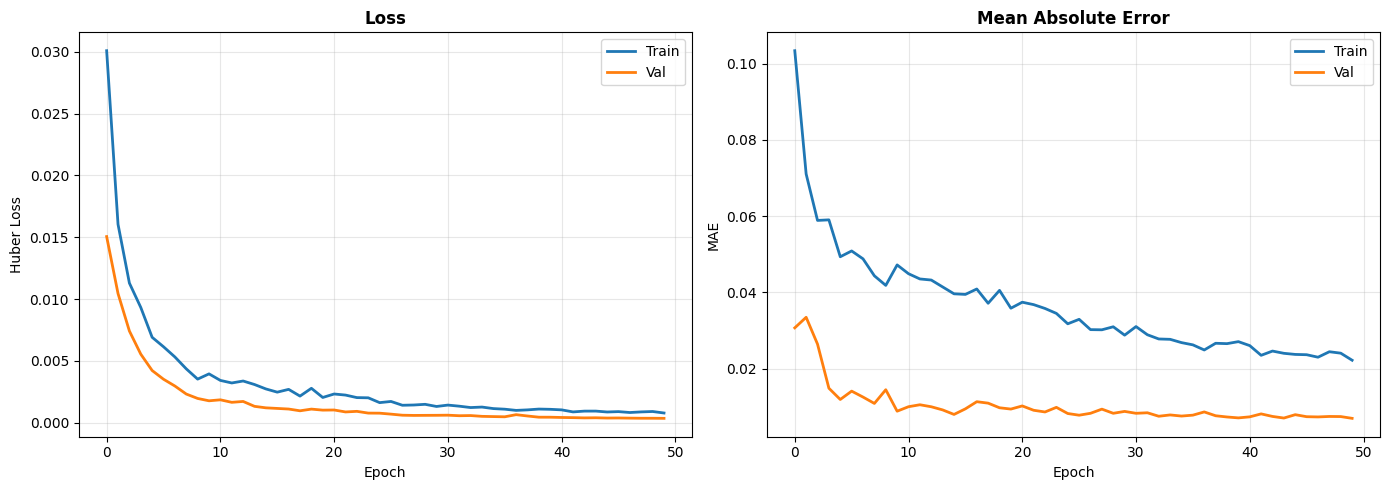

✓ Saved: training_history.png/json, final_model.keras


In [9]:
"""
Cell 8: Model Training (Memory-Optimized)
==========================================
Data generators feed batches on-demand from memory-mapped .npy files
"""

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from datetime import datetime
import time, json, gc

print("=" * 70)
print("MODEL TRAINING")
print("=" * 70)

BATCH_SIZE    = CONFIG['BATCH_SIZE']
EPOCHS        = CONFIG['EPOCHS']
LEARNING_RATE = 0.0005

print(f"\n⚙️  Batch: {BATCH_SIZE} | Epochs: {EPOCHS} | LR: {LEARNING_RATE}")

# Load memory-mapped data
print("\n📂 Loading data (memory-mapped)...")
X_train = np.load('X_train.npy', mmap_mode='r')
Y_train = np.load('Y_train.npy', mmap_mode='r')
X_test  = np.load('X_test.npy',  mmap_mode='r')
Y_test  = np.load('Y_test.npy',  mmap_mode='r')
print(f"   X_train: {X_train.shape}  X_test: {X_test.shape}")

class MemoryEfficientGenerator(tf.keras.utils.Sequence):
    def __init__(self, X, Y, batch_size, shuffle=True):
        self.X, self.Y = X, Y
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.indices = np.arange(len(X))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.X) / self.batch_size))

    def __getitem__(self, idx):
        s = idx * self.batch_size
        e = min(s + self.batch_size, len(self.X))
        bi = self.indices[s:e]
        return np.array(self.X[bi]), np.array(self.Y[bi])

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

train_gen = MemoryEfficientGenerator(X_train, Y_train, BATCH_SIZE, shuffle=True)
val_gen   = MemoryEfficientGenerator(X_test,  Y_test,  BATCH_SIZE, shuffle=False)
print(f"✓ Generators: {len(train_gen)} train / {len(val_gen)} val batches")

# Compile
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss=tf.keras.losses.Huber(delta=0.5),
    metrics=['mae'])

callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                          patience=5, min_lr=1e-7, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=12,
                                      restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ModelCheckpoint('best_model.keras', monitor='val_loss',
                                       save_best_only=True, verbose=1),
    tf.keras.callbacks.LambdaCallback(on_epoch_end=lambda e, l: gc.collect())
]

print("\n🚀 Training...")
print("=" * 70)
t0 = time.time()

history = model.fit(train_gen, validation_data=val_gen,
                    epochs=EPOCHS, callbacks=callbacks, verbose=1)

elapsed = time.time() - t0
print("\n" + "=" * 70)
print(f"✓ TRAINING COMPLETE — {elapsed / 60:.1f} min")
print(f"   Final train loss: {history.history['loss'][-1]:.6f}")
print(f"   Final val loss:   {history.history['val_loss'][-1]:.6f}")
print(f"   Final train MAE:  {history.history['mae'][-1]:.6f}")
print(f"   Final val MAE:    {history.history['val_mae'][-1]:.6f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train', lw=2)
axes[0].plot(history.history['val_loss'], label='Val', lw=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber Loss')
axes[0].set_title('Loss', fontweight='bold'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['mae'], label='Train', lw=2)
axes[1].plot(history.history['val_mae'], label='Val', lw=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].set_title('Mean Absolute Error', fontweight='bold'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Save history
h_dict = {k: [float(v) for v in vs] for k, vs in history.history.items()}
h_dict['training_time_minutes'] = elapsed / 60
h_dict['epochs_completed'] = len(history.history['loss'])
with open('training_history.json', 'w') as f:
    json.dump(h_dict, f, indent=2)

model.save('final_model.keras')
print("✓ Saved: training_history.png/json, final_model.keras")

del X_train, Y_train, train_gen; gc.collect()
print("=" * 70)

## Step 7: Model Evaluation

Standard hydrological forecasting metrics (Moriasi et al., 2007):
- **RMSE** (Root Mean Squared Error) — in meters; lower = better
- **MAE** (Mean Absolute Error) — in meters; lower = better
- **NSE** (Nash-Sutcliffe Efficiency) — [−∞, 1]; >0.75 very good, >0.50 satisfactory
- **R²** (Coefficient of Determination) — [0, 1]; 1 = perfect
- **PBIAS** (Percent Bias) — %; 0 = unbiased; + = overprediction, − = underprediction

MODEL EVALUATION — BUHI CONVLSTM FLOOD PREDICTOR

✓ Test samples: 300
  River level range: 0.0000 – 3.1500 m

🔮 Predicting on test set...
150/150 ━━━━━━━━━━━━━━━━━━━━ 57s 374ms/step

╔════════════════════════════════════════════════════════════╗
║           MODEL PERFORMANCE — LAKE BUHI                    ║
╠════════════════════════════════════════════════════════════╣
║   RMSE   = 0.0320 m                                       ║
║   MAE    = 0.0219 m                                       ║
║   NSE    = 0.4520    (Acceptable)                   ║
║   R²     = 0.4528    (Unsatisfactory)                   ║
║   PBIAS  = +3.19 %   (Very Good)                   ║
╠════════════════════════════════════════════════════════════╣
║   Test Samples: 300                                     ║
╚════════════════════════════════════════════════════════════╝

   Classification based on Moriasi et al. (2007)

📊 Per-Hour Forecast Performance:
   Hour    RMSE (m)   MAE (m)      NSE       R²  PBIAS (%)
   ─

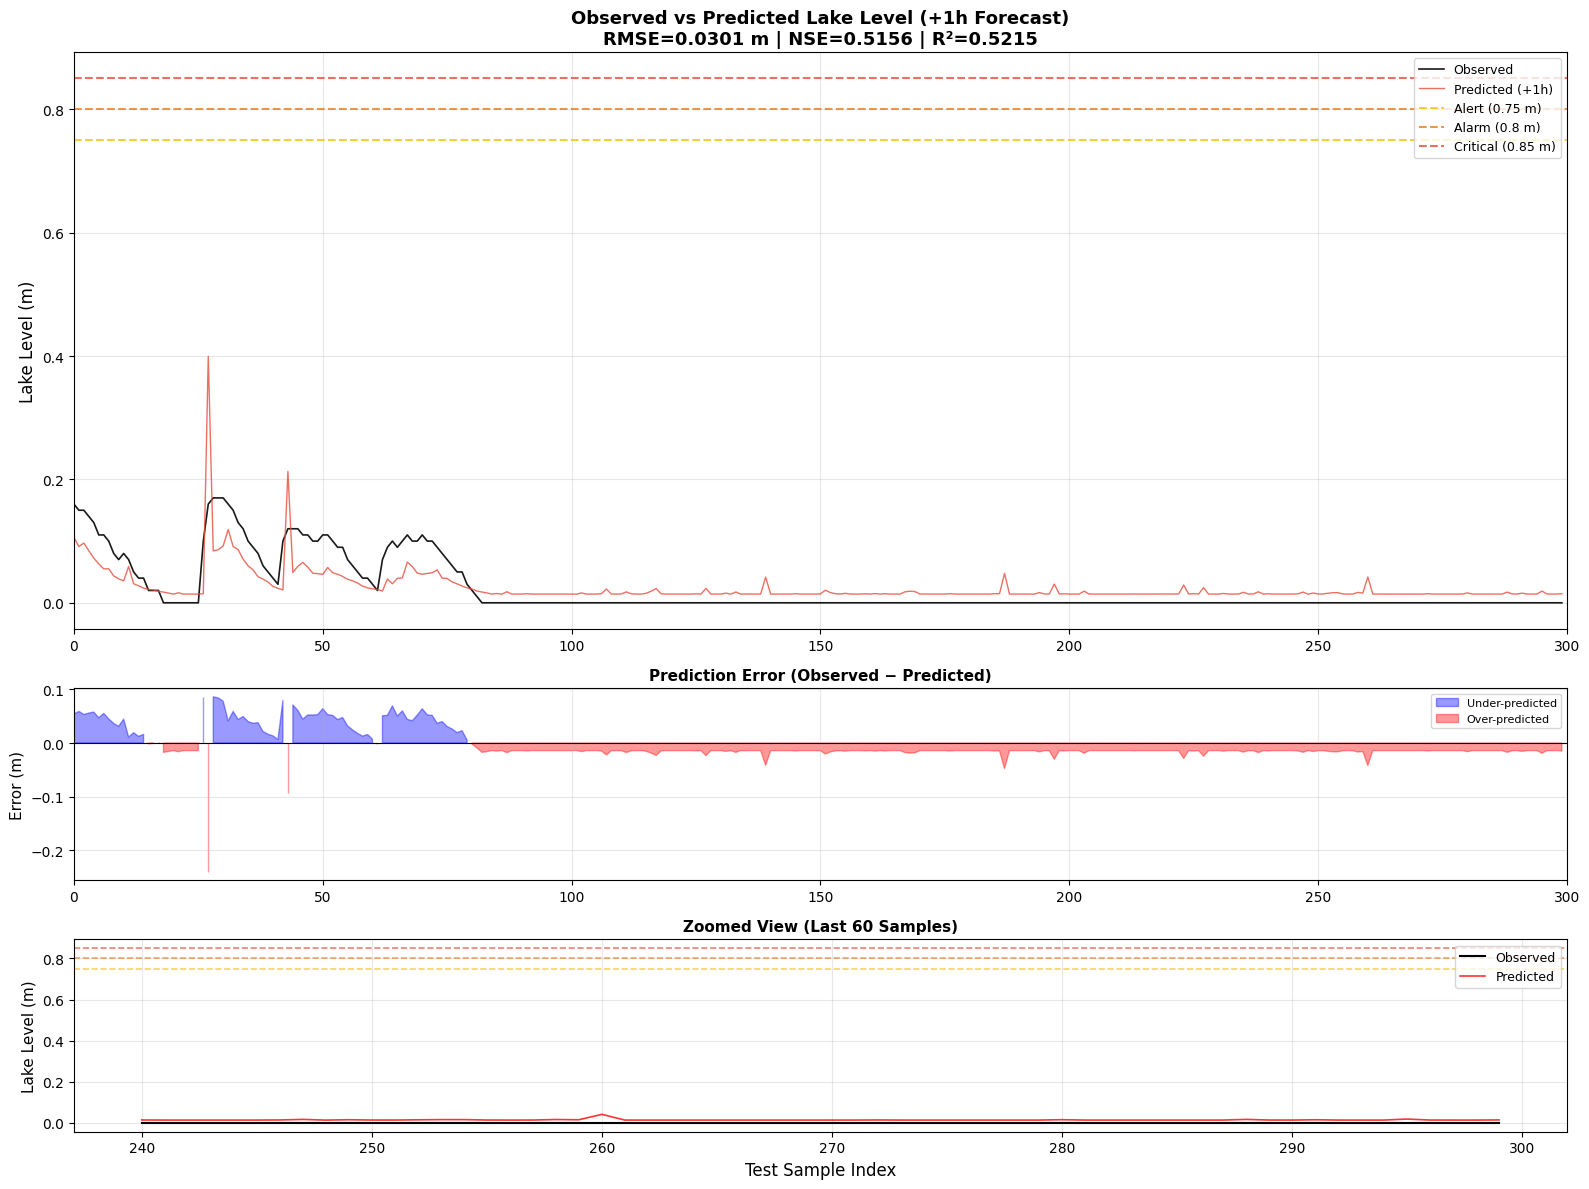

✓ Saved: fig_timeseries_comparison.png


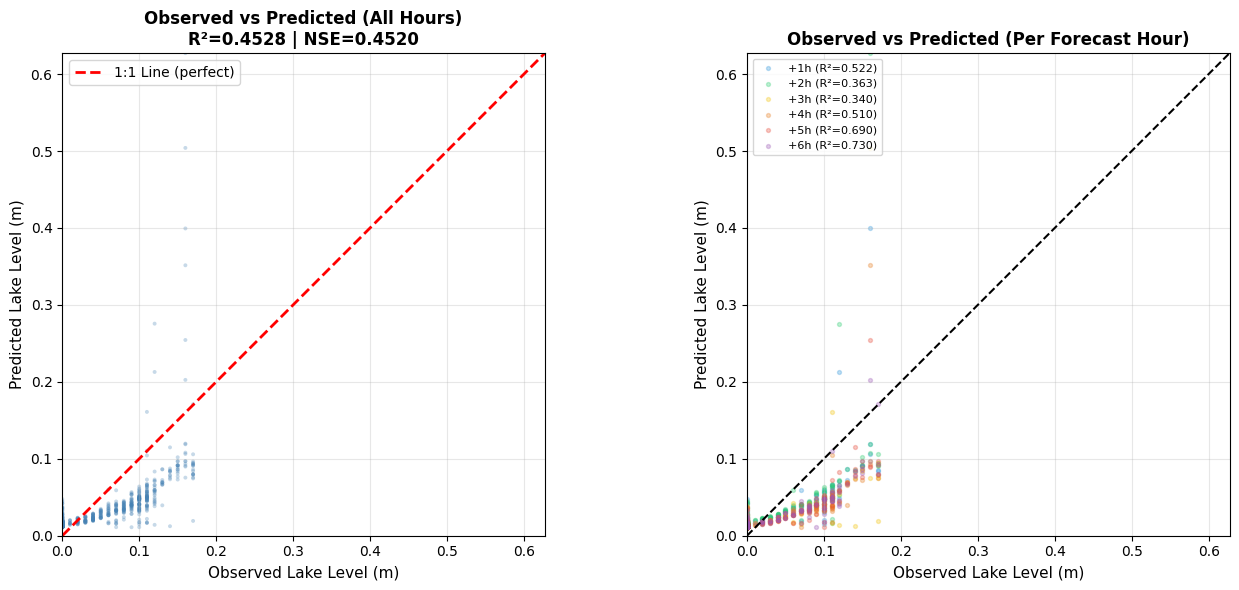

✓ Saved: fig_scatter_obs_vs_pred.png


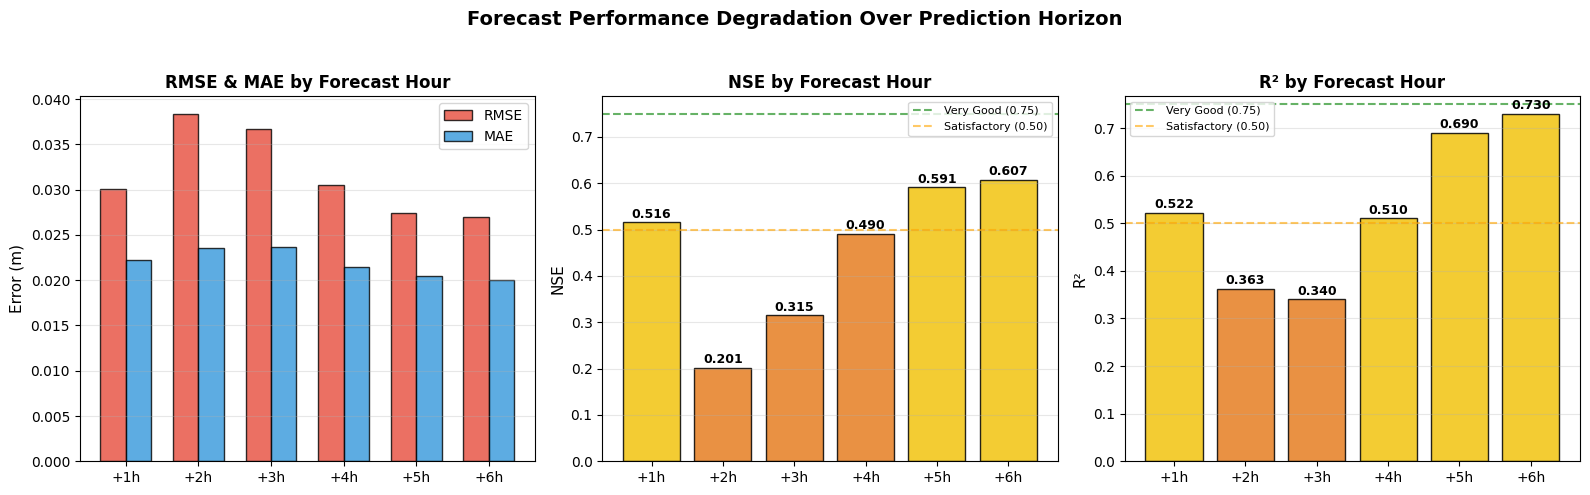

✓ Saved: fig_per_hour_performance.png


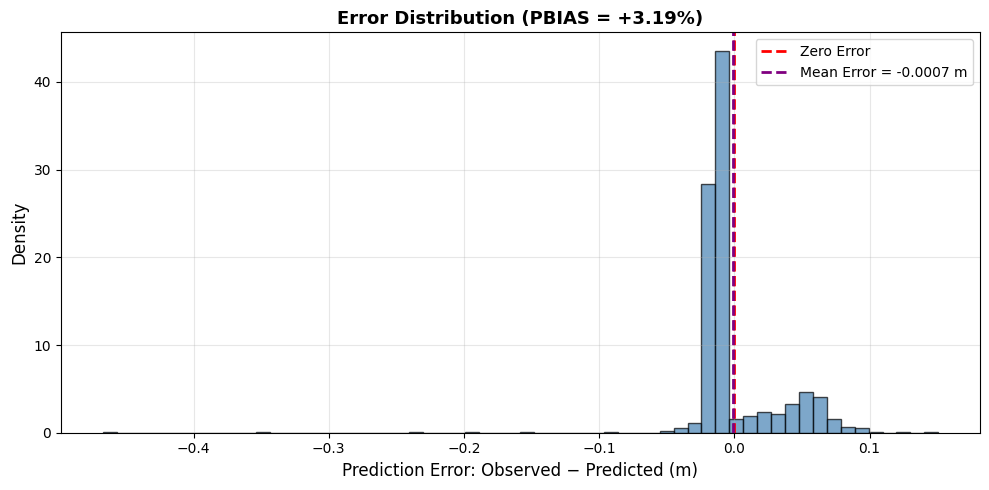

✓ Saved: fig_error_distribution.png

📁 Saved Files:
   evaluation_metrics.json    — all metrics (machine-readable)
   evaluation_summary.csv     — overall performance table
   evaluation_per_hour.csv    — per-hour performance table
   fig_timeseries_comparison.png  — observed vs predicted time series
   fig_scatter_obs_vs_pred.png    — scatter plot
   fig_per_hour_performance.png   — forecast degradation
   fig_error_distribution.png     — error histogram


In [1]:
"""
Cell 9: Model Evaluation — RMSE, MAE, NSE, R², PBIAS
=====================================================
Standard hydrological forecasting metrics (Moriasi et al., 2007)
+ Observed vs Predicted time series comparison
+ Per-hour forecast degradation analysis
"""

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.stats import pearsonr
import json, pandas as pd

# Load metadata (no more builtins hack)
with open('sequence_metadata.json') as f:
    seq_meta = json.load(f)

OUTPUT_HOURS = seq_meta['output_hours']

print("=" * 70)
print("MODEL EVALUATION — BUHI CONVLSTM FLOOD PREDICTOR")
print("=" * 70)

X_test = np.load('X_test.npy', mmap_mode='r')
Y_test = np.load('Y_test.npy', mmap_mode='r')

# Load model with custom_objects so Lambda layer resolves without builtins
def _extract_forecast(x):
    return x[:, -OUTPUT_HOURS:, :, :, :]

model = tf.keras.models.load_model(
    'best_model.keras', safe_mode=False,
    custom_objects={'extract_forecast': _extract_forecast})

with open('normalization_params.json') as f:
    norm_params = json.load(f)
river_min = norm_params['riverlevel']['min']
river_max = norm_params['riverlevel']['max']
thresholds = norm_params['thresholds']

print(f"✓ Test samples: {X_test.shape[0]}")
print(f"  River level range: {river_min:.4f} – {river_max:.4f} m")

# Predict
print("\n🔮 Predicting on test set...")
predictions = model.predict(X_test, batch_size=2, verbose=1)

# Denormalize (spatial mean per timestep)
y_true_norm = np.mean(Y_test[:, :, :, :, 0], axis=(2, 3))
y_pred_norm = np.mean(predictions[:, :, :, :, 0], axis=(2, 3))
y_true_m = y_true_norm * (river_max - river_min) + river_min
y_pred_m = y_pred_norm * (river_max - river_min) + river_min

yt = y_true_m.flatten()
yp = y_pred_m.flatten()

# ══════════════════════════════════════════════════════════════════════════
# METRIC FUNCTIONS (Moriasi et al., 2007)
# ══════════════════════════════════════════════════════════════════════════

def calc_rmse(obs, pred):
    """Root Mean Squared Error (m)"""
    return np.sqrt(mean_squared_error(obs, pred))

def calc_mae(obs, pred):
    """Mean Absolute Error (m)"""
    return mean_absolute_error(obs, pred)

def calc_nse(obs, pred):
    """Nash-Sutcliffe Efficiency [-∞, 1]"""
    ss_res = np.sum((obs - pred)**2)
    ss_tot = np.sum((obs - np.mean(obs))**2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0.0

def calc_r2(obs, pred):
    """Coefficient of Determination [0, 1]"""
    r_val, _ = pearsonr(obs, pred)
    return r_val ** 2

def calc_pbias(obs, pred):
    """Percent Bias (%) — positive = overprediction"""
    return 100 * np.sum(pred - obs) / np.sum(obs) if np.sum(obs) != 0 else 0.0

# ══════════════════════════════════════════════════════════════════════════
# OVERALL METRICS
# ══════════════════════════════════════════════════════════════════════════

RMSE  = calc_rmse(yt, yp)
MAE   = calc_mae(yt, yp)
NSE   = calc_nse(yt, yp)
R2    = calc_r2(yt, yp)
PBIAS = calc_pbias(yt, yp)

# NSE rating (Moriasi et al., 2007)
if NSE > 0.75:   rating = "Very Good"
elif NSE > 0.65: rating = "Good"
elif NSE > 0.50: rating = "Satisfactory"
elif NSE > 0:    rating = "Acceptable"
else:            rating = "Unsatisfactory"

# PBIAS rating (Moriasi et al., 2007 — streamflow)
abs_pbias = abs(PBIAS)
if abs_pbias < 10:    pbias_rating = "Very Good"
elif abs_pbias < 15:  pbias_rating = "Good"
elif abs_pbias < 25:  pbias_rating = "Satisfactory"
else:                 pbias_rating = "Unsatisfactory"

# R² rating
if R2 > 0.75:   r2_rating = "Very Good"
elif R2 > 0.65: r2_rating = "Good"
elif R2 > 0.50: r2_rating = "Satisfactory"
else:           r2_rating = "Unsatisfactory"

# ── Per-hour metrics ─────────────────────────────────────────────────────
hourly = []
for h in range(seq_meta['output_hours']):
    yt_h, yp_h = y_true_m[:, h], y_pred_m[:, h]
    hourly.append({
        'Forecast Hour': f'+{h+1}h',
        'RMSE (m)':  calc_rmse(yt_h, yp_h),
        'MAE (m)':   calc_mae(yt_h, yp_h),
        'NSE':       calc_nse(yt_h, yp_h),
        'R²':        calc_r2(yt_h, yp_h),
        'PBIAS (%)': calc_pbias(yt_h, yp_h),
    })

# ══════════════════════════════════════════════════════════════════════════
# DISPLAY RESULTS
# ══════════════════════════════════════════════════════════════════════════

print("\n╔" + "═"*60 + "╗")
print("║           MODEL PERFORMANCE — LAKE BUHI                    ║")
print("╠" + "═"*60 + "╣")
print(f"║   RMSE   = {RMSE:.4f} m                                       ║")
print(f"║   MAE    = {MAE:.4f} m                                       ║")
print(f"║   NSE    = {NSE:.4f}    ({rating})                   ║")
print(f"║   R²     = {R2:.4f}    ({r2_rating})                   ║")
print(f"║   PBIAS  = {PBIAS:+.2f} %   ({pbias_rating})                   ║")
print("╠" + "═"*60 + "╣")
print(f"║   Test Samples: {len(X_test):,}                                     ║")
print("╚" + "═"*60 + "╝")

print(f"\n   Classification based on Moriasi et al. (2007)")

# Per-hour table
print("\n📊 Per-Hour Forecast Performance:")
print(f"   {'Hour':<6} {'RMSE (m)':>9} {'MAE (m)':>9} {'NSE':>8} {'R²':>8} {'PBIAS (%)':>10}")
print(f"   {'─'*52}")
for m in hourly:
    print(f"   {m['Forecast Hour']:<6} {m['RMSE (m)']:>9.4f} {m['MAE (m)']:>9.4f} "
          f"{m['NSE']:>8.4f} {m['R²']:>8.4f} {m['PBIAS (%)']:>+10.2f}")

# Thesis-ready tables
summary_df = pd.DataFrame({
    'Metric': ['RMSE (m)', 'MAE (m)', 'NSE', 'R²', 'PBIAS (%)'],
    'Value':  [f'{RMSE:.4f}', f'{MAE:.4f}', f'{NSE:.4f}', f'{R2:.4f}', f'{PBIAS:+.2f}'],
    'Rating': ['-', '-', rating, r2_rating, pbias_rating]
})
hourly_df = pd.DataFrame(hourly)

print("\n📋 Overall Performance Table:")
print(summary_df.to_string(index=False))
print("\n📋 Per-Hour Performance Table:")
print(hourly_df.to_string(index=False))

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 1: Observed vs Predicted Time Series (MOST IMPORTANT FOR THESIS)
# ══════════════════════════════════════════════════════════════════════════

# Use +1h predictions for the clearest time series comparison
y_obs_1h = y_true_m[:, 0]   # observed at +1h
y_pred_1h = y_pred_m[:, 0]  # predicted at +1h
n_plot = len(y_obs_1h)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), gridspec_kw={'height_ratios': [3, 1, 1]})

# (a) Time series overlay
ax = axes[0]
time_idx = np.arange(n_plot)
ax.plot(time_idx, y_obs_1h, color='black', lw=1.2, alpha=0.9, label='Observed')
ax.plot(time_idx, y_pred_1h, color='#e74c3c', lw=1.0, alpha=0.8, label='Predicted (+1h)')
# Threshold lines
ax.axhline(thresholds['alert'],    color='#f1c40f', ls='--', lw=1.5, alpha=0.8, label=f"Alert ({thresholds['alert']} m)")
ax.axhline(thresholds['alarm'],    color='#e67e22', ls='--', lw=1.5, alpha=0.8, label=f"Alarm ({thresholds['alarm']} m)")
ax.axhline(thresholds['critical'], color='#e74c3c', ls='--', lw=1.5, alpha=0.8, label=f"Critical ({thresholds['critical']} m)")
ax.set_ylabel('Lake Level (m)', fontsize=12)
ax.set_title(f'Observed vs Predicted Lake Level (+1h Forecast)\n'
             f'RMSE={hourly[0]["RMSE (m)"]:.4f} m | NSE={hourly[0]["NSE"]:.4f} | R²={hourly[0]["R²"]:.4f}',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, n_plot)

# (b) Prediction error over time
ax = axes[1]
error_1h = y_obs_1h - y_pred_1h
ax.fill_between(time_idx, error_1h, 0, where=error_1h >= 0, color='blue', alpha=0.4, label='Under-predicted')
ax.fill_between(time_idx, error_1h, 0, where=error_1h < 0, color='red', alpha=0.4, label='Over-predicted')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Error (m)', fontsize=11)
ax.set_title('Prediction Error (Observed − Predicted)', fontsize=11, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, n_plot)

# (c) Zoomed section (last 200 samples or 20% of data)
ax = axes[2]
zoom_n = min(200, n_plot // 5)
ax.plot(time_idx[-zoom_n:], y_obs_1h[-zoom_n:], 'k-', lw=1.5, label='Observed')
ax.plot(time_idx[-zoom_n:], y_pred_1h[-zoom_n:], 'r-', lw=1.2, alpha=0.8, label='Predicted')
ax.axhline(thresholds['alert'],    color='#f1c40f', ls='--', lw=1.2, alpha=0.7)
ax.axhline(thresholds['alarm'],    color='#e67e22', ls='--', lw=1.2, alpha=0.7)
ax.axhline(thresholds['critical'], color='#e74c3c', ls='--', lw=1.2, alpha=0.7)
ax.set_xlabel('Test Sample Index', fontsize=12)
ax.set_ylabel('Lake Level (m)', fontsize=11)
ax.set_title(f'Zoomed View (Last {zoom_n} Samples)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_timeseries_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: fig_timeseries_comparison.png")

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 2: Scatter Plot — Observed vs Predicted
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) All hours combined
ax = axes[0]
ax.scatter(yt, yp, alpha=0.3, s=8, c='steelblue', edgecolors='none')
lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
ax.plot(lims, lims, 'r--', lw=2, label='1:1 Line (perfect)')
ax.set_xlabel('Observed Lake Level (m)', fontsize=11)
ax.set_ylabel('Predicted Lake Level (m)', fontsize=11)
ax.set_title(f'Observed vs Predicted (All Hours)\nR²={R2:.4f} | NSE={NSE:.4f}',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')

# (b) Per-hour colored scatter
ax = axes[1]
colors_hr = ['#3498db', '#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6']
for h in range(seq_meta['output_hours']):
    ax.scatter(y_true_m[:, h], y_pred_m[:, h], alpha=0.3, s=8,
               color=colors_hr[h], label=f"+{h+1}h (R²={hourly[h]['R²']:.3f})")
ax.plot(lims, lims, 'k--', lw=1.5)
ax.set_xlabel('Observed Lake Level (m)', fontsize=11)
ax.set_ylabel('Predicted Lake Level (m)', fontsize=11)
ax.set_title('Observed vs Predicted (Per Forecast Hour)', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left'); ax.grid(True, alpha=0.3)
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('fig_scatter_obs_vs_pred.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: fig_scatter_obs_vs_pred.png")

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 3: Per-Hour Performance Degradation
# ══════════════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
hrs = [m['Forecast Hour'] for m in hourly]
x_pos = np.arange(len(hrs))

# (a) RMSE & MAE by hour
ax = axes[0]
w = 0.35
ax.bar(x_pos - w/2, [m['RMSE (m)'] for m in hourly], w,
       color='#e74c3c', edgecolor='black', alpha=0.8, label='RMSE')
ax.bar(x_pos + w/2, [m['MAE (m)'] for m in hourly], w,
       color='#3498db', edgecolor='black', alpha=0.8, label='MAE')
ax.set_xticks(x_pos); ax.set_xticklabels(hrs)
ax.set_ylabel('Error (m)', fontsize=11)
ax.set_title('RMSE & MAE by Forecast Hour', fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3, axis='y')

# (b) NSE by hour
ax = axes[1]
nse_vals = [m['NSE'] for m in hourly]
nse_colors = ['#2ecc71' if n > 0.75 else '#f1c40f' if n > 0.5 else '#e67e22' if n > 0 else '#e74c3c'
              for n in nse_vals]
bars = ax.bar(x_pos, nse_vals, color=nse_colors, edgecolor='black', alpha=0.85)
for b, v in zip(bars, nse_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
ax.axhline(0.75, color='green', ls='--', lw=1.5, alpha=0.6, label='Very Good (0.75)')
ax.axhline(0.50, color='orange', ls='--', lw=1.5, alpha=0.6, label='Satisfactory (0.50)')
ax.set_xticks(x_pos); ax.set_xticklabels(hrs)
ax.set_ylabel('NSE', fontsize=11)
ax.set_title('NSE by Forecast Hour', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

# (c) R² by hour
ax = axes[2]
r2_vals = [m['R²'] for m in hourly]
r2_colors = ['#2ecc71' if n > 0.75 else '#f1c40f' if n > 0.5 else '#e67e22' if n > 0 else '#e74c3c'
             for n in r2_vals]
bars = ax.bar(x_pos, r2_vals, color=r2_colors, edgecolor='black', alpha=0.85)
for b, v in zip(bars, r2_vals):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
            f'{v:.3f}', ha='center', fontweight='bold', fontsize=9)
ax.axhline(0.75, color='green', ls='--', lw=1.5, alpha=0.6, label='Very Good (0.75)')
ax.axhline(0.50, color='orange', ls='--', lw=1.5, alpha=0.6, label='Satisfactory (0.50)')
ax.set_xticks(x_pos); ax.set_xticklabels(hrs)
ax.set_ylabel('R²', fontsize=11)
ax.set_title('R² by Forecast Hour', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Forecast Performance Degradation Over Prediction Horizon',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('fig_per_hour_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: fig_per_hour_performance.png")

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 4: Error Distribution
# ══════════════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 5))
errors = yt - yp
ax.hist(errors, bins=60, color='steelblue', edgecolor='black', alpha=0.7, density=True)
ax.axvline(0, color='red', ls='--', lw=2, label='Zero Error')
ax.axvline(np.mean(errors), color='purple', ls='--', lw=2,
           label=f'Mean Error = {np.mean(errors):+.4f} m')
ax.set_xlabel('Prediction Error: Observed − Predicted (m)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Error Distribution (PBIAS = {PBIAS:+.2f}%)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: fig_error_distribution.png")

# ══════════════════════════════════════════════════════════════════════════
# SAVE ALL RESULTS
# ══════════════════════════════════════════════════════════════════════════

results = {
    'overall': {
        'RMSE_m': float(RMSE),
        'MAE_m': float(MAE),
        'NSE': float(NSE),
        'R2': float(R2),
        'PBIAS_pct': float(PBIAS),
        'NSE_rating': rating,
        'R2_rating': r2_rating,
        'PBIAS_rating': pbias_rating,
    },
    'per_hour': [{k: float(v) if isinstance(v, (float, np.floating)) else v
                  for k, v in m.items()} for m in hourly],
    'test_samples': int(len(X_test)),
    'reference': 'Moriasi et al. (2007)'
}
with open('evaluation_metrics.json', 'w') as f:
    json.dump(results, f, indent=2)

summary_df.to_csv('evaluation_summary.csv', index=False)
hourly_df.to_csv('evaluation_per_hour.csv', index=False)

print("\n📁 Saved Files:")
print("   evaluation_metrics.json    — all metrics (machine-readable)")
print("   evaluation_summary.csv     — overall performance table")
print("   evaluation_per_hour.csv    — per-hour performance table")
print("   fig_timeseries_comparison.png  — observed vs predicted time series")
print("   fig_scatter_obs_vs_pred.png    — scatter plot")
print("   fig_per_hour_performance.png   — forecast degradation")
print("   fig_error_distribution.png     — error histogram")
print("=" * 70)

## Step 8: Lake-Overflow Flood Estimation (FWDET)

**How it works with the Lake Buhi shapefile:**

1. The **lake mask** (rasterized from `BUHI_LAKE.shp`) defines the water body exactly
2. The **bank elevation** is derived from DTM pixels at the lake boundary
3. When the predicted lake level exceeds the **overflow threshold**, water
   *spills from the lake boundary* and propagates into adjacent lower terrain
4. **Flood depth** = water surface elevation − terrain elevation

This is much more accurate than the old gradient-based water-body detection
because we know the lake's true shape from the shapefile.

LAKE-OVERFLOW FLOOD ESTIMATION (FWDET)
✓ DEM: (128, 128) | elev 54.1–1198.3 m
✓ Lake mask: 1517 px
✓ Lake surface: 80.60 m | bank: 81.01 m
✓ Overflow threshold: 0.8 m
✓ Test samples: 300

🔍 Selecting sample with highest lake activity...
✓ Sample 27

📊 Hourly Forecast (overflow > 0.8 m):
   Hr      Pred    True Level      Overflow  Land %
   -----------------------------------------------
   +1h    0.66m   0.16m NORMAL            —    0.0%
   +2h    0.57m   0.16m NORMAL            —    0.0%
   +3h    0.50m   0.16m NORMAL            —    0.0%
   +4h    0.43m   0.16m NORMAL            —    0.0%
   +5h    0.36m   0.16m NORMAL            —    0.0%
   +6h    0.31m   0.17m NORMAL            —    0.0%

📊 Creating visualization...


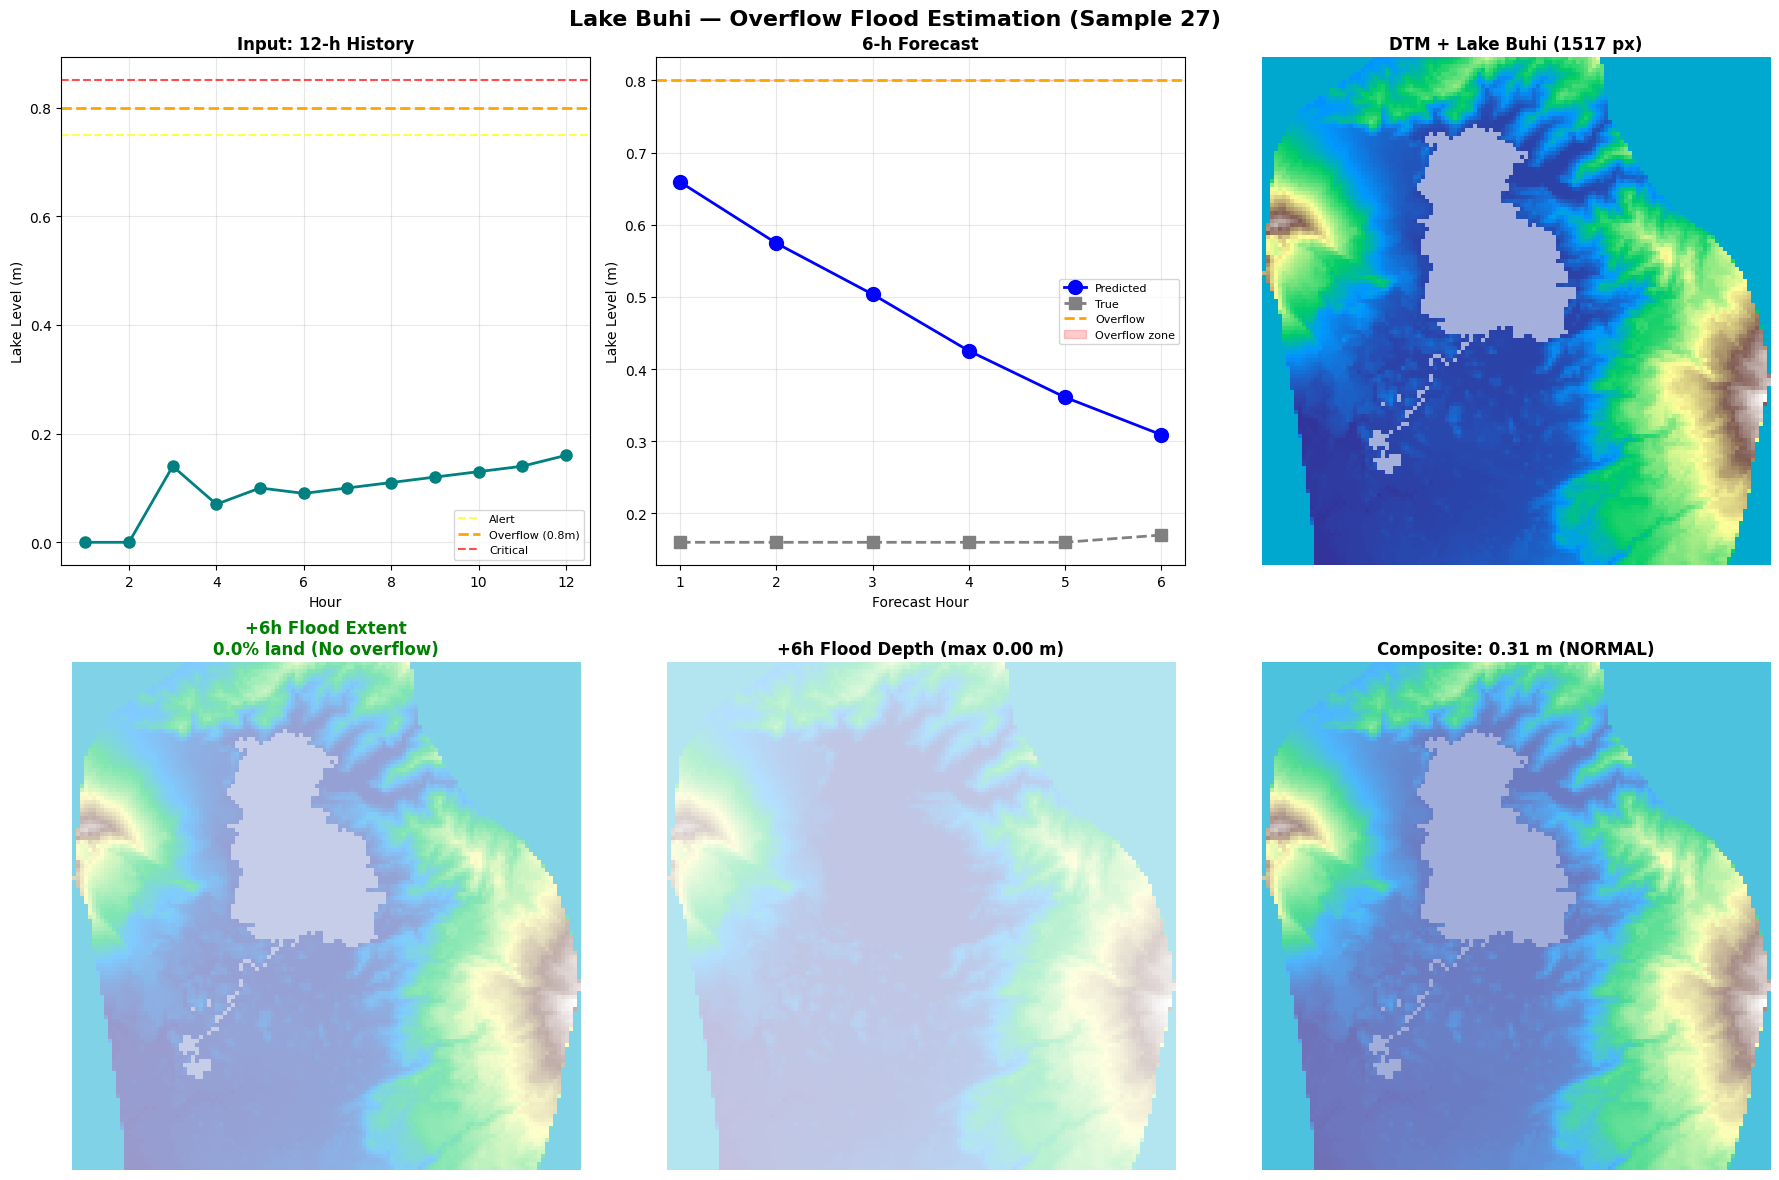

✓ Saved: fwdet_summary.png

📊 Hourly progression...


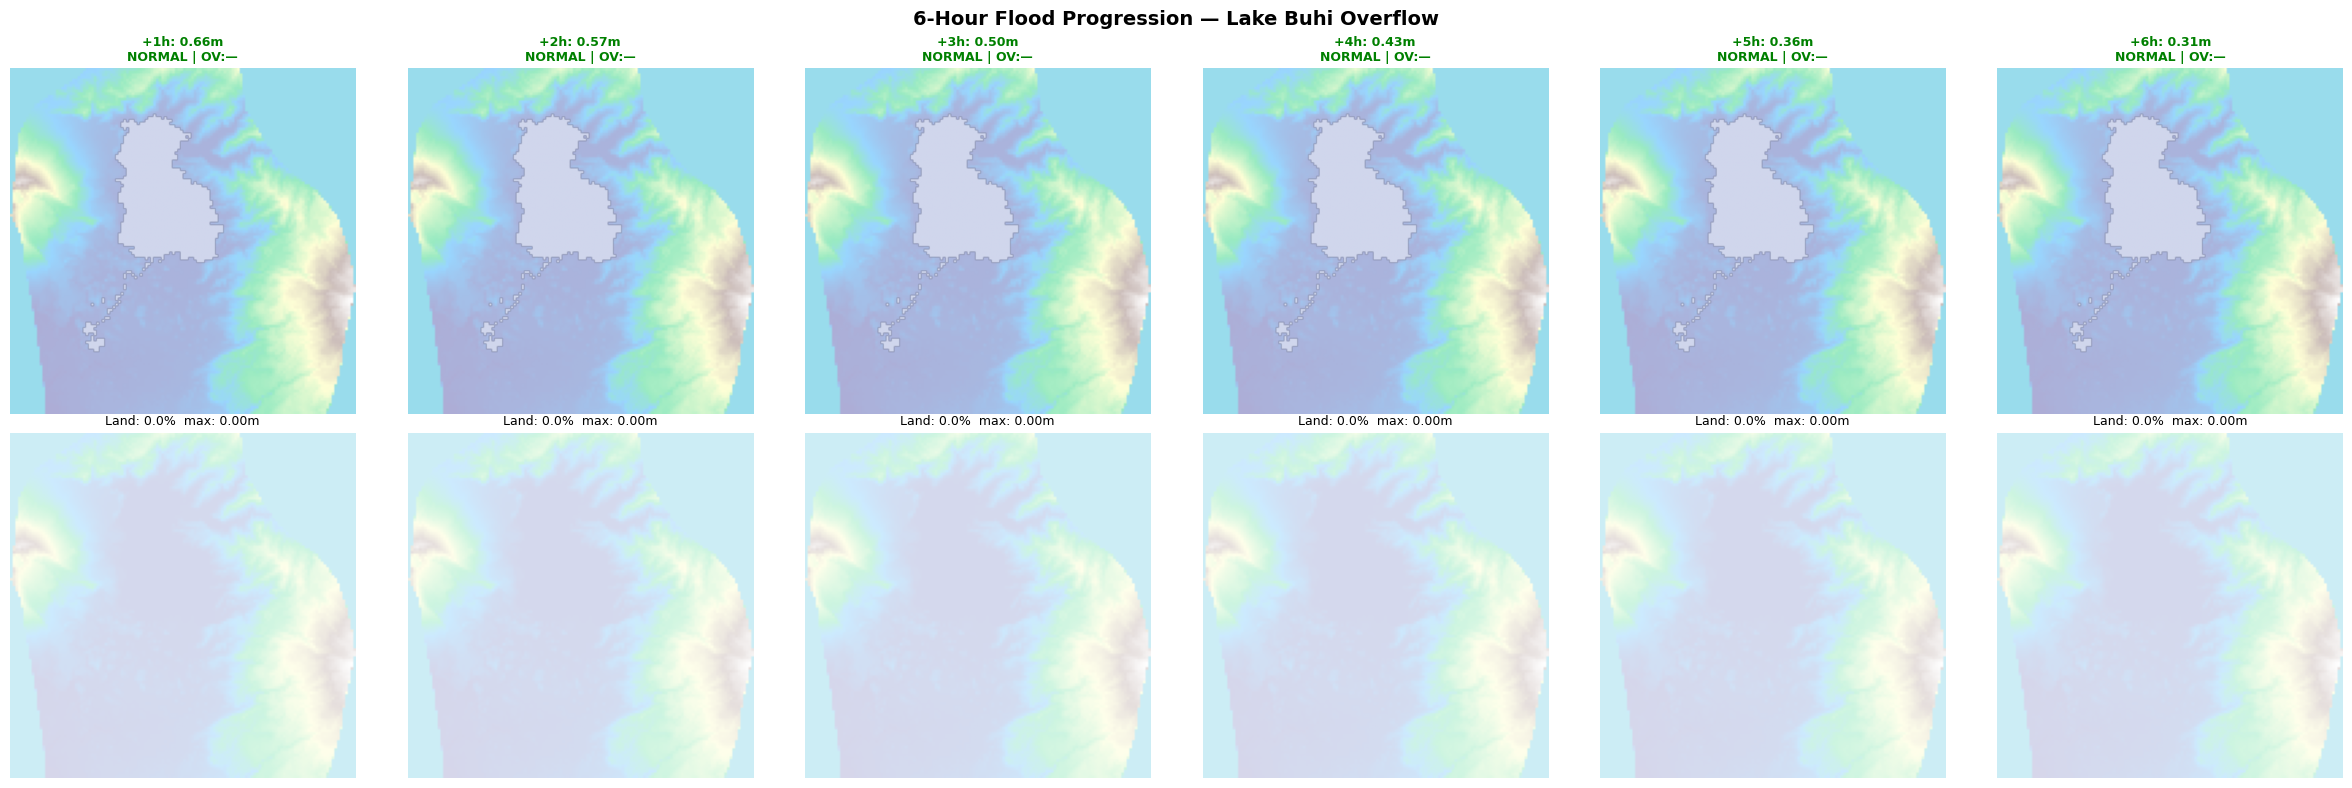

✓ Saved: fwdet_hourly_progression.png


In [2]:
"""
Cell 10: Lake-Overflow Flood Estimation (FWDET)
================================================
Uses the rasterized BUHI_LAKE.shp mask as the overflow source.
Flooding starts FROM the lake boundary when predicted level > threshold.
"""

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation
import json

# Load metadata (no builtins hack)
with open('sequence_metadata.json') as f:
    seq_meta = json.load(f)
OUTPUT_HOURS = seq_meta['output_hours']

print("=" * 70)
print("LAKE-OVERFLOW FLOOD ESTIMATION (FWDET)")
print("=" * 70)

# ── Load data ──
dem        = np.load('dem_small.npy')
dem_norm   = np.load('dem_small_norm.npy')
lake_mask  = np.load('lake_small.npy')         # from shapefile
X_test     = np.load('X_test.npy', mmap_mode='r')
Y_test     = np.load('Y_test.npy', mmap_mode='r')

with open('normalization_params.json') as f:
    norm_params = json.load(f)
with open('dem_metadata.json') as f:
    dem_meta = json.load(f)

# Load model with custom_objects (no builtins dependency)
def _extract_forecast(x):
    return x[:, -OUTPUT_HOURS:, :, :, :]

model = tf.keras.models.load_model(
    'best_model.keras', safe_mode=False,
    custom_objects={'extract_forecast': _extract_forecast})

river_min  = norm_params['riverlevel']['min']
river_max  = norm_params['riverlevel']['max']
thresholds = norm_params['thresholds']

# Lake geometry from metadata
lake_surface_elev = dem_meta['lake']['surface_elev']
lake_bank_elev    = dem_meta['lake']['bank_elev']

# Overflow threshold: use CONFIG alarm level
OVERFLOW_THRESHOLD = thresholds['alarm']   # 2.4 m

print(f"✓ DEM: {dem.shape} | elev {dem.min():.1f}–{dem.max():.1f} m")
print(f"✓ Lake mask: {int(lake_mask.sum())} px")
print(f"✓ Lake surface: {lake_surface_elev:.2f} m | bank: {lake_bank_elev:.2f} m")
print(f"✓ Overflow threshold: {OVERFLOW_THRESHOLD:.1f} m")
print(f"✓ Test samples: {len(X_test)}")

# ── Helpers ──
def denorm(v):
    return v * (river_max - river_min) + river_min

def warning_level(v):
    if v >= thresholds['critical']: return 'CRITICAL', 'red'
    if v >= thresholds['alarm']:    return 'ALARM', 'orange'
    if v >= thresholds['alert']:    return 'ALERT', 'yellow'
    return 'NORMAL', 'green'

def estimate_flood(lake_level_m, dem, lake_mask, lake_bank, overflow_thresh):
    """
    Lake-overflow flood estimation.
    Water spills FROM the lake boundary into adjacent terrain below the
    computed water-surface elevation.

    Returns (flood_extent, flood_depth, stats_dict)
    """
    flood_ext = np.zeros_like(dem, dtype=bool)
    flood_dep = np.zeros_like(dem, dtype=np.float32)

    if lake_level_m <= overflow_thresh:
        return flood_ext, flood_dep, {
            'overflowing': False, 'overflow_depth': 0.0,
            'flooded_land_pct': 0.0, 'max_depth': 0.0, 'mean_depth': 0.0,
            'water_surface': 0.0}

    overflow_depth = lake_level_m - overflow_thresh
    water_surface  = lake_bank + overflow_depth

    struct = np.ones((3, 3))                        # 8-connectivity
    boundary = binary_dilation(lake_mask > 0, struct) & (lake_mask == 0)

    flood_ext = boundary & (dem <= water_surface)

    # Iterative flood fill
    for _ in range(300):
        expanded = binary_dilation(flood_ext, struct)
        new = expanded & (dem <= water_surface) & ~flood_ext & (lake_mask == 0)
        if not new.any():
            break
        flood_ext |= new

    flood_dep[flood_ext] = np.maximum(0, water_surface - dem[flood_ext])

    land_px = dem.size - int(lake_mask.sum())
    fl_px   = int(flood_ext.sum())
    pct     = 100 * fl_px / land_px if land_px > 0 else 0
    mx      = float(flood_dep.max()) if fl_px > 0 else 0
    mn      = float(flood_dep[flood_ext].mean()) if fl_px > 0 else 0

    return flood_ext, flood_dep, {
        'overflowing': True, 'overflow_depth': float(overflow_depth),
        'flooded_land_pct': float(pct), 'max_depth': mx, 'mean_depth': mn,
        'water_surface': float(water_surface)}

# ── Find an active test sample ──
print("\n🔍 Selecting sample with highest lake activity...")
best_idx, best_score = 0, 0
for idx in range(min(100, len(X_test))):
    rl = denorm(X_test[idx, :, 0, 0, 1])
    sc = np.mean(rl) + 2 * np.std(rl)
    if sc > best_score:
        best_score, best_idx = sc, idx

print(f"✓ Sample {best_idx}")

# Predict
pred = model.predict(X_test[best_idx:best_idx+1], verbose=0)

print(f"\n📊 Hourly Forecast (overflow > {OVERFLOW_THRESHOLD:.1f} m):")
print(f"   {'Hr':<4} {'Pred':>7} {'True':>7} {'Level':<9} {'Overflow':>9} {'Land %':>7}")
print(f"   {'-'*47}")

hourly_results = []
for h in range(seq_meta['output_hours']):
    pn = pred[0, h, 0, 0, 0]
    tn = Y_test[best_idx, h, 0, 0, 0]
    pm = denorm(pn);  tm = denorm(tn)
    lv, cl = warning_level(pm)

    fext, fdep, st = estimate_flood(pm, dem, lake_mask, lake_bank_elev, OVERFLOW_THRESHOLD)
    ov = f"+{st['overflow_depth']:.2f}m" if st['overflowing'] else "—"
    hourly_results.append(dict(hour=h+1, pred=pm, true=tm, level=lv, color=cl,
                               extent=fext, depth=fdep, stats=st))
    print(f"   +{h+1}h  {pm:>6.2f}m {tm:>6.2f}m {lv:<9} {ov:>9} {st['flooded_land_pct']:>6.1f}%")

# ── Summary plot ──
print("\n📊 Creating visualization...")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# (a) 12-h input history
ax = axes[0, 0]
inp = [denorm(X_test[best_idx, t, 0, 0, 1]) for t in range(seq_meta['input_hours'])]
ax.plot(range(1, 13), inp, 'o-', color='teal', lw=2, ms=8)
ax.axhline(thresholds['alert'],  color='yellow', ls='--', alpha=0.7, label='Alert')
ax.axhline(OVERFLOW_THRESHOLD,   color='orange', ls='--', lw=2, label=f'Overflow ({OVERFLOW_THRESHOLD}m)')
ax.axhline(thresholds['critical'], color='red', ls='--', alpha=0.7, label='Critical')
ax.set_xlabel('Hour'); ax.set_ylabel('Lake Level (m)')
ax.set_title('Input: 12-h History', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (b) Predicted vs True
ax = axes[0, 1]
hrs = [r['hour'] for r in hourly_results]
ax.plot(hrs, [r['pred'] for r in hourly_results], 'o-', color='blue', lw=2, ms=10, label='Predicted')
ax.plot(hrs, [r['true'] for r in hourly_results], 's--', color='gray', lw=2, ms=8, label='True')
ax.axhline(OVERFLOW_THRESHOLD, color='orange', ls='--', lw=2, label='Overflow')
ax.fill_between(hrs, OVERFLOW_THRESHOLD,
                [max(r['pred'], OVERFLOW_THRESHOLD) for r in hourly_results],
                alpha=0.2, color='red', label='Overflow zone')
ax.set_xlabel('Forecast Hour'); ax.set_ylabel('Lake Level (m)')
ax.set_title('6-h Forecast', fontweight='bold'); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# (c) DTM + Lake overlay
ax = axes[0, 2]
ax.imshow(dem, cmap='terrain')
ax.imshow(np.ma.masked_where(lake_mask == 0, lake_mask), cmap='Blues', alpha=0.6)
ax.set_title(f'DTM + Lake Buhi ({int(lake_mask.sum())} px)', fontweight='bold'); ax.axis('off')

# (d) Final-hour flood extent
fin = hourly_results[-1]
ax = axes[1, 0]
ax.imshow(dem, cmap='terrain', alpha=0.5)
ax.imshow(np.ma.masked_where(lake_mask == 0, lake_mask), cmap='Blues', alpha=0.5)
if fin['extent'].any():
    ax.imshow(np.ma.masked_where(~fin['extent'], np.ones_like(dem)), cmap='Reds', alpha=0.6)
ov_tag = f"+{fin['stats']['overflow_depth']:.2f}m" if fin['stats']['overflowing'] else "No overflow"
ax.set_title(f"+6h Flood Extent\n{fin['stats']['flooded_land_pct']:.1f}% land ({ov_tag})",
             fontweight='bold', color=fin['color']); ax.axis('off')

# (e) Flood depth
ax = axes[1, 1]
ax.imshow(dem, cmap='terrain', alpha=0.3)
if fin['extent'].any():
    im = ax.imshow(np.ma.masked_where(~fin['extent'], fin['depth']), cmap='Blues', vmin=0)
    plt.colorbar(im, ax=ax, label='Depth (m)', shrink=0.8)
ax.set_title(f"+6h Flood Depth (max {fin['stats']['max_depth']:.2f} m)", fontweight='bold')
ax.axis('off')

# (f) Composite
ax = axes[1, 2]
ax.imshow(dem, cmap='terrain', alpha=0.7)
ax.imshow(np.ma.masked_where(lake_mask == 0, lake_mask), cmap='Blues', alpha=0.4)
if fin['extent'].any():
    ax.imshow(np.ma.masked_where(~fin['extent'], fin['depth']), cmap='Reds', alpha=0.6, vmin=0)
ax.set_title(f"Composite: {fin['pred']:.2f} m ({fin['level']})", fontweight='bold'); ax.axis('off')

plt.suptitle(f'Lake Buhi — Overflow Flood Estimation (Sample {best_idx})',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('fwdet_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: fwdet_summary.png")

# ── Hourly progression ──
print("\n📊 Hourly progression...")
fig, axes = plt.subplots(2, 6, figsize=(24, 8))
mx_d = max((r['stats']['max_depth'] for r in hourly_results), default=1) or 0.1

for h, r in enumerate(hourly_results):
    # Row 0: extent
    ax = axes[0, h]
    ax.imshow(dem, cmap='terrain', alpha=0.4)
    ax.imshow(np.ma.masked_where(lake_mask == 0, lake_mask), cmap='Blues', alpha=0.5)
    if r['extent'].any():
        ax.imshow(np.ma.masked_where(~r['extent'], np.ones_like(dem)), cmap='Reds', alpha=0.6)
    ot = f"+{r['stats']['overflow_depth']:.1f}m" if r['stats']['overflowing'] else "—"
    ax.set_title(f"+{r['hour']}h: {r['pred']:.2f}m\n{r['level']} | OV:{ot}", fontsize=9,
                 fontweight='bold', color=r['color']); ax.axis('off')

    # Row 1: depth
    ax = axes[1, h]
    ax.imshow(dem, cmap='terrain', alpha=0.2)
    if r['extent'].any():
        ax.imshow(np.ma.masked_where(~r['extent'], r['depth']),
                  cmap='Blues', vmin=0, vmax=mx_d)
    ax.set_title(f"Land: {r['stats']['flooded_land_pct']:.1f}%  max: {r['stats']['max_depth']:.2f}m",
                 fontsize=9); ax.axis('off')

plt.suptitle('6-Hour Flood Progression — Lake Buhi Overflow',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('fwdet_hourly_progression.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: fwdet_hourly_progression.png")
print("=" * 70)

## Step 9: Interactive Flood Prediction Demo

Enter custom 12-hour rainfall and lake-level values, then see the predicted
6-hour lake level and the resulting flood extent from Lake Buhi overflow.

Modify `custom_rainfall` and `custom_river_level` arrays below and re-run.

INTERACTIVE FLOOD PREDICTION DEMO — LAKE BUHI

📥 Rainfall:   5.0–95.0 mm
   Lake level: 1.20–4.00 m

✓ Lake mask: 23 components, kept 3 (≥5 px), removed 20 tiny fragments (31 px total)
   Lake centroid: row=49, col=55 (of 128×128 grid)
   Lake bounds:   rows [17–104], cols [27–78]

🌊 Terrain around lake boundary:
   Bank elevation (P95 of lake DEM): 81.01 m
   Boundary terrain: min=79.59, mean=97.84, max=182.29 m
   To start flooding boundary: need lake level > -0.62 m

📊 6-Hour Scenario (overflow > 0.80 m):
   Hr      Model   Scenario Level      Overflow  WaterSurf   Land%
   ------------------------------------------------------------------
   +1h     1.50m      2.80m CRITICAL     +2.00m     83.01m    6.1%
   +2h     1.47m      3.10m CRITICAL     +2.30m     83.31m    6.4%
   +3h     1.46m      3.40m CRITICAL     +2.60m     83.61m    6.8%
   +4h     1.46m      3.65m CRITICAL     +2.85m     83.86m    7.1%
   +5h     1.45m      3.85m CRITICAL     +3.05m     84.06m    7.3%
   +6h     1.4

C:\Users\Selwyn Lao\AppData\Local\Temp\ipykernel_4828\1332415049.py:205: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.08, 1, 0.95])


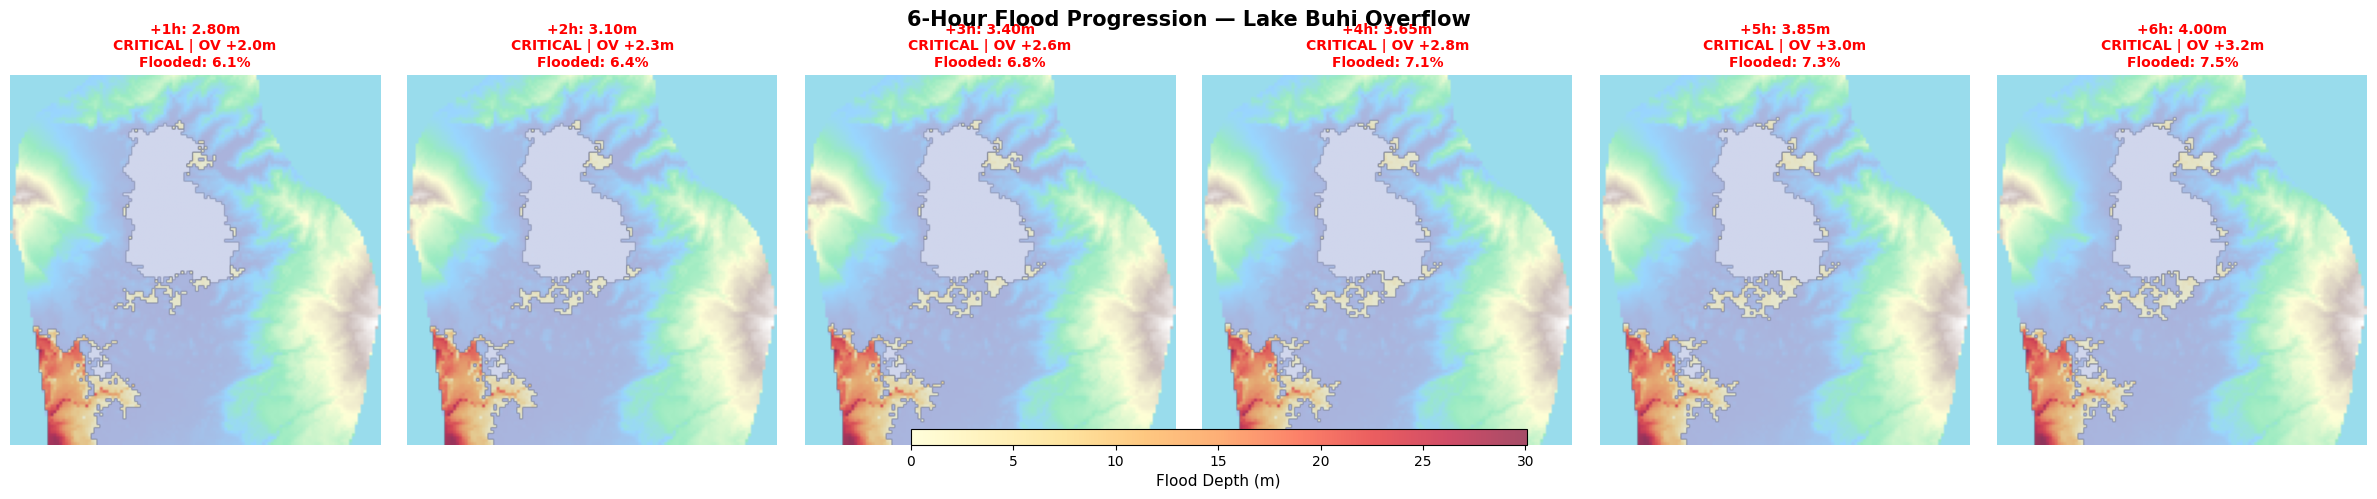

✓ Saved: demo_flood_progression.png

📊 Generating statistics figure...


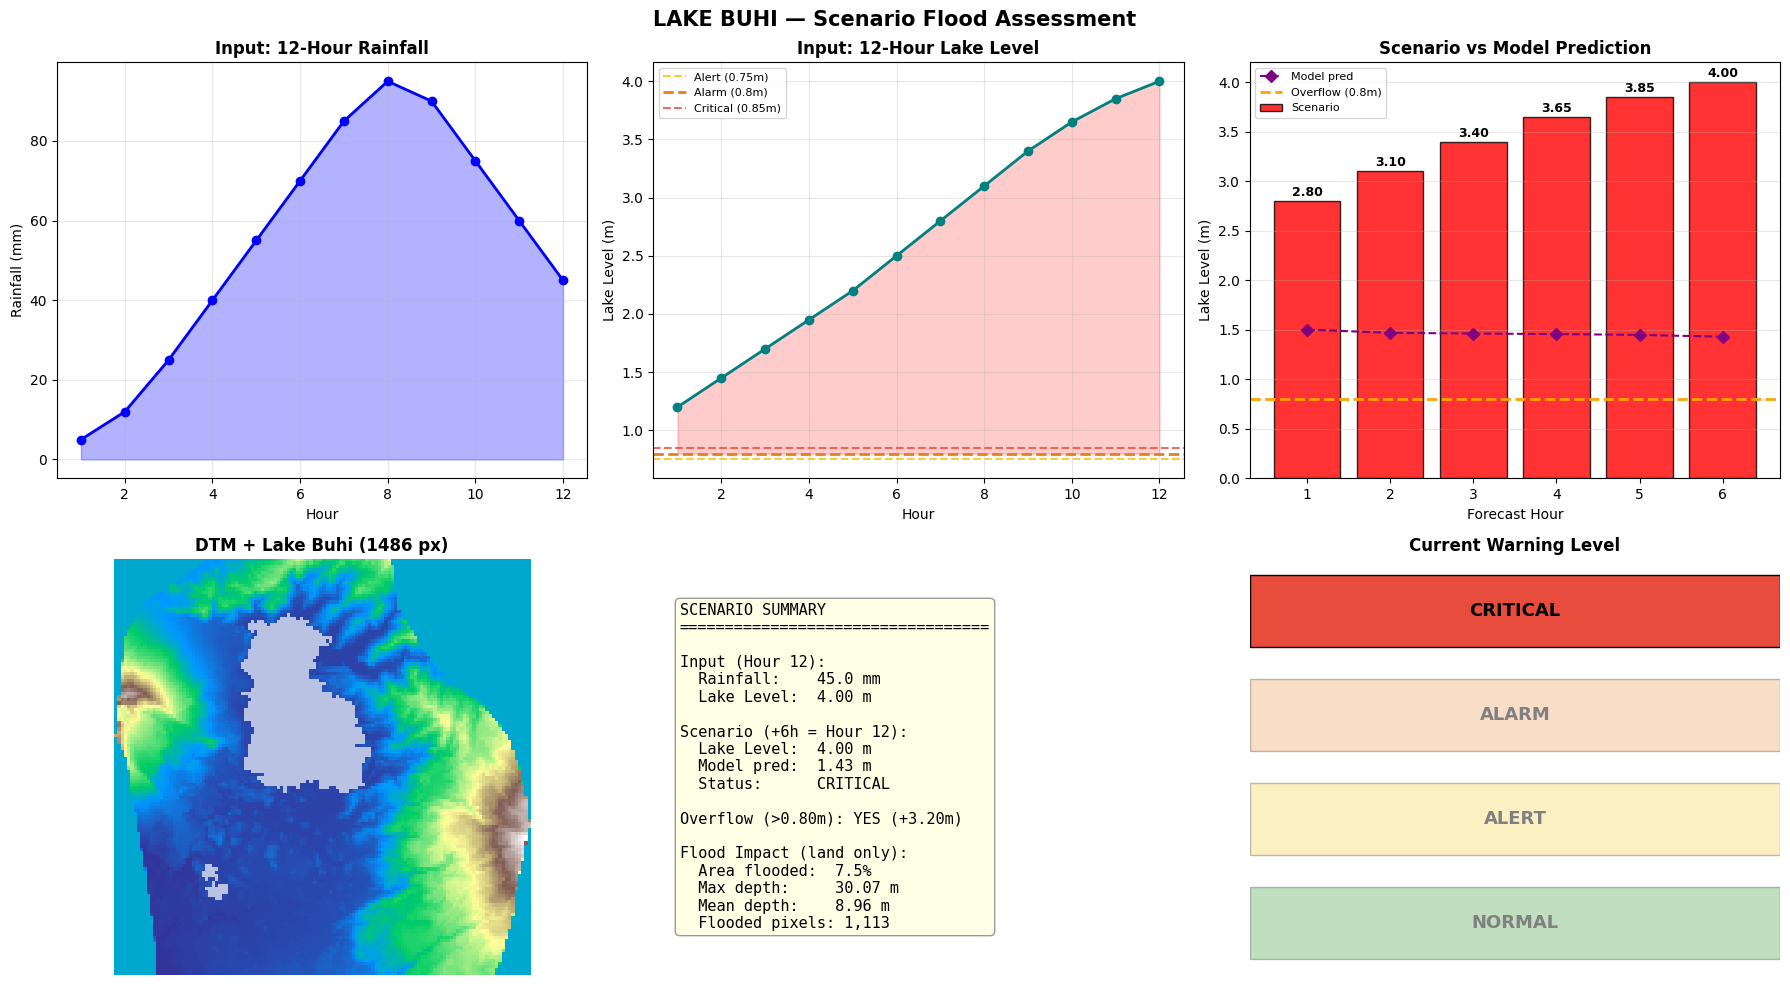

✓ Saved: demo_statistics.png

💡 TIP: Edit custom_rainfall / custom_river_level above and re-run!
   Flooding triggers when lake level > 0.80 m


In [11]:
"""
Cell 11: Interactive Flood Prediction Demo
==========================================
Custom inputs → ConvLSTM forecast → lake-overflow flood mapping
"""

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, label
import json

# Load metadata (no builtins hack)
with open('sequence_metadata.json') as f:
    seq_meta = json.load(f)
OUTPUT_HOURS = seq_meta['output_hours']

print("=" * 70)
print("INTERACTIVE FLOOD PREDICTION DEMO — LAKE BUHI")
print("=" * 70)

# ════════════════════════════════════════════════════════════════════════════
# CUSTOMIZE YOUR INPUTS HERE
# ════════════════════════════════════════════════════════════════════════════

custom_rainfall = [            # 12 hours (mm) — severe typhoon scenario
    5.0, 12.0, 25.0, 40.0, 55.0, 70.0,
    85.0, 95.0, 90.0, 75.0, 60.0, 45.0
]

custom_river_level = [         # 12 hours (meters) — rapid rise past overflow
    1.20, 1.45, 1.70, 1.95, 2.20, 2.50,
    2.80, 3.10, 3.40, 3.65, 3.85, 4.00
]

# ════════════════════════════════════════════════════════════════════════════

print(f"\n📥 Rainfall:   {min(custom_rainfall):.1f}–{max(custom_rainfall):.1f} mm")
print(f"   Lake level: {min(custom_river_level):.2f}–{max(custom_river_level):.2f} m")

# Norm params
with open('normalization_params.json') as f:
    norm_params = json.load(f)
rain_min, rain_max   = norm_params['rainfall']['min'],   norm_params['rainfall']['max']
river_min, river_max = norm_params['riverlevel']['min'], norm_params['riverlevel']['max']
thresholds = norm_params['thresholds']

rainfall_n = np.clip([(r - rain_min)  / (rain_max - rain_min)   if rain_max > rain_min else 0
                      for r in custom_rainfall], 0, 1)
river_n    = np.clip([(r - river_min) / (river_max - river_min) if river_max > river_min else 0
                      for r in custom_river_level], 0, 1)

# Spatial arrays
dem       = np.load('dem_small.npy')
dem_norm  = np.load('dem_small_norm.npy')
lake_mask = np.load('lake_small.npy')

with open('dem_metadata.json') as f:
    dm = json.load(f)
lake_bank_elev = dm['lake']['bank_elev']

OVERFLOW_THRESHOLD = thresholds['alarm']

h, w = seq_meta['input_shape'][1], seq_meta['input_shape'][2]
n_ch = 4

# ── Clean the lake mask: only remove tiny noise fragments (< 5 px) ────────
# The lake may have multiple disconnected parts (e.g., the bottom-left lobe).
# We keep ALL real components; only remove truly tiny noise (< 5 pixels).
labeled_lake, n_lake_features = label(lake_mask > 0)
if n_lake_features > 1:
    component_sizes = [(i, int(np.sum(labeled_lake == i)))
                       for i in range(1, n_lake_features + 1)]
    MIN_COMPONENT_PX = 5   # only remove isolated noise, not real lake parts
    keep_ids = [cid for cid, sz in component_sizes if sz >= MIN_COMPONENT_PX]
    lake_clean = np.isin(labeled_lake, keep_ids).astype(np.float32)
    removed = [sz for _, sz in component_sizes if sz < MIN_COMPONENT_PX]
    print(f"\n✓ Lake mask: {n_lake_features} components, kept {len(keep_ids)} "
          f"(≥{MIN_COMPONENT_PX} px), removed {len(removed)} tiny fragments "
          f"({sum(removed)} px total)")
else:
    lake_clean = (lake_mask > 0).astype(np.float32)
    print(f"\n✓ Lake mask: single component, {int(lake_clean.sum())} px")

# Diagnostics
lake_rows, lake_cols = np.where(lake_clean > 0)
print(f"   Lake centroid: row={lake_rows.mean():.0f}, col={lake_cols.mean():.0f} "
      f"(of {h}×{w} grid)")
print(f"   Lake bounds:   rows [{lake_rows.min()}–{lake_rows.max()}], "
      f"cols [{lake_cols.min()}–{lake_cols.max()}]")

struct_diag = np.ones((3, 3))
bnd_diag = binary_dilation(lake_clean > 0, struct_diag) & (lake_clean == 0)
bnd_elevations = dem[bnd_diag]
print(f"\n🌊 Terrain around lake boundary:")
print(f"   Bank elevation (P95 of lake DEM): {lake_bank_elev:.2f} m")
print(f"   Boundary terrain: min={bnd_elevations.min():.2f}, "
      f"mean={bnd_elevations.mean():.2f}, max={bnd_elevations.max():.2f} m")
print(f"   To start flooding boundary: need lake level > "
      f"{OVERFLOW_THRESHOLD + (bnd_elevations.min() - lake_bank_elev):.2f} m")

# Build input
inp = np.zeros((1, 12, h, w, n_ch), dtype=np.float32)
for t in range(12):
    inp[0, t, :, :, 0] = rainfall_n[t]
    inp[0, t, :, :, 1] = river_n[t]
    inp[0, t, :, :, 2] = dem_norm
    inp[0, t, :, :, 3] = lake_mask

# Load model
def _extract_forecast(x):
    return x[:, -OUTPUT_HOURS:, :, :, :]

model = tf.keras.models.load_model(
    'best_model.keras', safe_mode=False,
    custom_objects={'extract_forecast': _extract_forecast})
pred  = model.predict(inp, verbose=0)

denorm = lambda v: v * (river_max - river_min) + river_min

def get_level(v):
    if v >= thresholds['critical']: return 'CRITICAL', 'red'
    if v >= thresholds['alarm']:    return 'ALARM', 'orange'
    if v >= thresholds['alert']:    return 'ALERT', 'yellow'
    return 'NORMAL', 'green'

def flood_wb(lm, dem, lmask_clean, bank, ov_t):
    """FWDET flood fill — starts from lake boundary, expands to low terrain."""
    fext = np.zeros_like(dem, dtype=bool)
    fdep = np.zeros_like(dem, dtype=np.float32)
    if lm <= ov_t:
        return fext, fdep, {'overflowing': False, 'overflow_depth': 0,
                            'flooded_land_pct': 0, 'max_depth': 0, 'mean_depth': 0}
    od = lm - ov_t
    ws = bank + od
    st = np.ones((3, 3))
    bnd = binary_dilation(lmask_clean > 0, st) & (lmask_clean == 0)
    fext = bnd & (dem <= ws)
    for _ in range(500):
        exp = binary_dilation(fext, st)
        nw  = exp & (dem <= ws) & ~fext & (lmask_clean == 0)
        if not nw.any(): break
        fext |= nw
    fdep[fext] = np.maximum(0, ws - dem[fext])
    lp = dem.size - int(lmask_clean.sum())
    fp = int(fext.sum())
    return fext, fdep, {
        'overflowing': True, 'overflow_depth': float(od),
        'water_surface': float(ws),
        'flooded_land_pct': 100*fp/lp if lp else 0,
        'max_depth': float(fdep.max()) if fp else 0,
        'mean_depth': float(fdep[fext].mean()) if fp else 0,
        'flooded_pixels': fp}

# ── Scenario levels: use input hours 7-12 as the 6-hour projection ───────
# The model prediction is informational; flood maps use YOUR scenario levels
# so the "what-if" visualization accurately reflects the levels you entered.
scenario_levels = custom_river_level[6:12]   # hours 7–12 → forecast +1h–+6h

print(f"\n📊 6-Hour Scenario (overflow > {OVERFLOW_THRESHOLD:.2f} m):")
print(f"   {'Hr':<4} {'Model':>8} {'Scenario':>10} {'Level':<9} {'Overflow':>9} {'WaterSurf':>10} {'Land%':>7}")
print(f"   {'-'*66}")

results = []
for hr in range(6):
    model_pred = denorm(pred[0, hr, 0, 0, 0])   # model's prediction (shown)
    scene_lev  = scenario_levels[hr]              # scenario level (used for flood)
    lv, cl = get_level(scene_lev)
    fext, fdep, st = flood_wb(scene_lev, dem, lake_clean, lake_bank_elev, OVERFLOW_THRESHOLD)
    ov = f"+{st['overflow_depth']:.2f}m" if st['overflowing'] else "No"
    ws_str = f"{st.get('water_surface', 0):.2f}m" if st['overflowing'] else "—"
    results.append(dict(hour=hr+1, pred=model_pred, scene=scene_lev,
                        level=lv, color=cl,
                        extent=fext, depth=fdep, stats=st))
    print(f"   +{hr+1}h  {model_pred:>7.2f}m {scene_lev:>9.2f}m {lv:<9} {ov:>9} {ws_str:>10} "
          f"{st['flooded_land_pct']:>6.1f}%")

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 1: 6-Hour Flood Progression
# ══════════════════════════════════════════════════════════════════════════
print("\n📊 Generating flood progression figure...")
max_depth_all = max((r['stats']['max_depth'] for r in results), default=0.1) or 0.1

fig, axes = plt.subplots(1, 6, figsize=(24, 5))
for i, r in enumerate(results):
    ax = axes[i]
    ax.imshow(dem, cmap='terrain', alpha=0.4)
    ax.imshow(np.ma.masked_where(lake_clean == 0, lake_clean), cmap='Blues', alpha=0.5)
    if r['extent'].any():
        depth_vis = np.ma.masked_where(~r['extent'], r['depth'])
        im = ax.imshow(depth_vis, cmap='YlOrRd', alpha=0.7, vmin=0, vmax=max_depth_all)
    tag = f"OV +{r['stats']['overflow_depth']:.1f}m" if r['stats']['overflowing'] else "No overflow"
    ax.set_title(f"+{r['hour']}h: {r['scene']:.2f}m\n{r['level']} | {tag}\n"
                 f"Flooded: {r['stats']['flooded_land_pct']:.1f}%",
                 fontweight='bold', fontsize=10, color=r['color'])
    ax.axis('off')

if any(r['extent'].any() for r in results):
    cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.04,
                        pad=0.08, aspect=40)
    cbar.set_label('Flood Depth (m)', fontsize=11)

plt.suptitle('6-Hour Flood Progression — Lake Buhi Overflow',
             fontsize=15, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.savefig('demo_flood_progression.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: demo_flood_progression.png")

# ══════════════════════════════════════════════════════════════════════════
# FIGURE 2: Input & Forecast Statistics
# ══════════════════════════════════════════════════════════════════════════
print("\n📊 Generating statistics figure...")
fin = results[-1]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
ax.plot(range(1, 13), custom_rainfall, 'o-', color='blue', lw=2)
ax.fill_between(range(1, 13), custom_rainfall, alpha=0.3, color='blue')
ax.set_xlabel('Hour'); ax.set_ylabel('Rainfall (mm)')
ax.set_title('Input: 12-Hour Rainfall', fontweight='bold'); ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.plot(range(1, 13), custom_river_level, 'o-', color='teal', lw=2)
ax.axhline(thresholds['alert'], color='#f1c40f', ls='--', alpha=0.8, label=f"Alert ({thresholds['alert']}m)")
ax.axhline(thresholds['alarm'], color='#e67e22', ls='--', lw=2, label=f"Alarm ({thresholds['alarm']}m)")
ax.axhline(thresholds['critical'], color='#e74c3c', ls='--', alpha=0.8, label=f"Critical ({thresholds['critical']}m)")
ax.fill_between(range(1, 13), OVERFLOW_THRESHOLD,
                [max(r, OVERFLOW_THRESHOLD) for r in custom_river_level], alpha=0.2, color='red')
ax.set_xlabel('Hour'); ax.set_ylabel('Lake Level (m)')
ax.set_title('Input: 12-Hour Lake Level', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[0, 2]
# Show scenario levels (solid) and model predictions (dashed) side by side
scene_vals = [r['scene'] for r in results]
model_vals = [r['pred'] for r in results]
hrs_plot = [r['hour'] for r in results]
bars = ax.bar(hrs_plot, scene_vals,
              color=[r['color'] for r in results], edgecolor='black', alpha=0.8, label='Scenario')
for b, r in zip(bars, results):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.05,
            f"{r['scene']:.2f}", ha='center', fontweight='bold', fontsize=9)
ax.plot(hrs_plot, model_vals, 'D--', color='purple', ms=6, lw=1.5, label='Model pred')
ax.axhline(OVERFLOW_THRESHOLD, color='orange', ls='--', lw=2, label=f'Overflow ({OVERFLOW_THRESHOLD}m)')
ax.set_xlabel('Forecast Hour'); ax.set_ylabel('Lake Level (m)')
ax.set_title('Scenario vs Model Prediction', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3, axis='y')

ax = axes[1, 0]
ax.imshow(dem, cmap='terrain')
ax.imshow(np.ma.masked_where(lake_clean == 0, lake_clean), cmap='Blues', alpha=0.7)
ax.set_title(f'DTM + Lake Buhi ({int(lake_clean.sum())} px)', fontweight='bold'); ax.axis('off')

ax = axes[1, 1]; ax.axis('off')
ovs = f"YES (+{fin['stats']['overflow_depth']:.2f}m)" if fin['stats']['overflowing'] else "NO"
txt = (f"SCENARIO SUMMARY\n{'='*34}\n\n"
       f"Input (Hour 12):\n"
       f"  Rainfall:    {custom_rainfall[-1]:.1f} mm\n"
       f"  Lake Level:  {custom_river_level[-1]:.2f} m\n\n"
       f"Scenario (+6h = Hour 12):\n"
       f"  Lake Level:  {fin['scene']:.2f} m\n"
       f"  Model pred:  {fin['pred']:.2f} m\n"
       f"  Status:      {fin['level']}\n\n"
       f"Overflow (>{OVERFLOW_THRESHOLD:.2f}m): {ovs}\n\n"
       f"Flood Impact (land only):\n"
       f"  Area flooded:  {fin['stats']['flooded_land_pct']:.1f}%\n"
       f"  Max depth:     {fin['stats']['max_depth']:.2f} m\n"
       f"  Mean depth:    {fin['stats']['mean_depth']:.2f} m\n"
       f"  Flooded pixels: {fin['stats'].get('flooded_pixels', 0):,}")
ax.text(0.05, 0.5, txt, fontsize=11, family='monospace', va='center',
        bbox=dict(boxstyle='round', fc='lightyellow', ec='gray', alpha=0.8))

ax = axes[1, 2]; ax.axis('off')
levels_list  = ['NORMAL', 'ALERT', 'ALARM', 'CRITICAL']
colors_list  = ['green', '#f1c40f', '#e67e22', '#e74c3c']
cur = levels_list.index(fin['level'])
for i, (lv, cl) in enumerate(zip(levels_list, colors_list)):
    ax.barh(i, 1, color=cl, alpha=1.0 if i == cur else 0.25, edgecolor='black', height=0.7)
    ax.text(0.5, i, lv, ha='center', va='center', fontweight='bold', fontsize=13,
            color='black' if i == cur else 'gray')
ax.set_xlim(0, 1); ax.set_ylim(-0.5, 3.5)
ax.set_title('Current Warning Level', fontweight='bold', fontsize=12)

plt.suptitle('LAKE BUHI — Scenario Flood Assessment',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('demo_statistics.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: demo_statistics.png")

print("\n💡 TIP: Edit custom_rainfall / custom_river_level above and re-run!")
print(f"   Flooding triggers when lake level > {OVERFLOW_THRESHOLD:.2f} m")
print("=" * 70)

## Important Notes & Next Steps

### File Structure Expected:
```
📁 ConvLSTM Model v3/
├── Buhi_ConvLSTM_V3.ipynb      ← this notebook
├── BUHI_DTM.tif                ← Digital Terrain Model
├── BUHI_LAKE.shp               ← Lake Buhi polygon
├── BUHI_LAKE.cpg               ← (companion files for .shp)
├── BUHI_LAKE.dbf
├── BUHI_LAKE.prj
├── BUHI_LAKE.qmd
├── BUHI_Rainfall-Data.csv      ← Hourly rainfall time series
├── BUHI_Riverlevel-Data.csv    ← Hourly lake/river level time series
└── BUHI_station_metadata.csv   ← Station coordinates
```

### Key Concepts:

| Term | Meaning |
|------|---------|
| **DTM** | Digital Terrain Model — bare-earth elevation (no buildings/trees) |
| **Lake mask** | Rasterized from BUHI_LAKE.shp — true shape of the lake on the grid |
| **Bank elevation** | 95th-percentile elevation of DTM pixels under the lake mask |
| **Overflow threshold** | The lake level (meters) above which water spills over the banks |
| **FWDET** | Floodwater Depth Estimation — flood fills outward from the lake boundary |

### Flood Mechanism:
1. Rainfall → lake level rises (predicted by ConvLSTM)
2. When lake level **exceeds the overflow/alarm threshold** (0.80 m),
   the water-surface elevation = bank elevation + overflow depth
3. Water propagates **from the lake boundary** into adjacent terrain
4. Any land pixel with elevation **below the water surface** gets flooded
5. Flood depth = water surface − terrain elevation

### Thresholds (from Buhi river level station):

| Level | Value | Color | Action |
|-------|-------|-------|--------|
| Normal | < 0.75 m | — | No action |
| Alert | 0.75 – 0.79 m | 🟡 Yellow | Monitor closely |
| Alarm | 0.80 – 0.84 m | 🟠 Orange | **Overflow starts** — evacuate low areas |
| Critical | ≥ 0.85 m | 🔴 Red | Major flooding — full evacuation |

### To Improve (Future Work):
1. Collect GPS-tagged flood event photos for validation
2. Get historical flood extent maps from DRRMO
3. Calibrate overflow threshold with observed flood events
4. Add bathymetry data for Lake Buhi (if available)
5. Incorporate multiple rainfall stations around the lake catchment